# Análisis del impacto educacional del uso de IA

---

In [68]:
import os, sys
import polars as pl

script_path = os.getcwd()
project_path = os.path.join(script_path, '..', '..', '..')

data_filename = 'processed_forms_interactions_data.parquet'
data_path = os.path.join(project_path, 'data', 'combined', data_filename)

sys.path.append(project_path)
from src.utils.educational_impact_analysis import (
    group_stats,
    plot_cat_distribution,
    plot_cat_comparison,
    plot_quant_distribution,
    plot_quant_comparison
)

forms_interactions_df = pl.read_parquet(data_path)


---

## Vista de la tabla

In [69]:
forms_interactions_df

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use,experimental_type_freq_quality,grupo_segmented
str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,str,str,str,i64,i64,bool,bool,bool,str,f64,str,bool,str,str
"""RamiroMaeztu-ks0""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,"""Alta""","""Alta""","""Alta""",0.6,0.2,0.8,0.4,"""Media""","""Baja""","""Media""","""Baja""",1.0,0.4,1.0,1.0,"""Alta""","""Baja""","""Media""","""Alta""",0.8,0.43,0.27,"""Media""","""Media""","""Baja""",2,5,true,true,true,"""Media""",1.5,"""Superficial""",false,"""ExpBB""","""ExpBB"""
"""RamiroMaeztu-pu9""","""RamiroMaeztu""","""experimental""",1.0,0.0,1.0,"""Alta""","""Baja""","""Alta""",0.8,0.48,1.0,0.6,"""Alta""","""Media""","""Alta""","""Media""",1.0,0.55,1.0,1.0,"""Alta""","""Media""","""Media""","""Alta""",0.2,0.4,0.27,"""Baja""","""Media""","""Baja""",8,5,false,true,true,"""Alta""",1.625,"""Superficial""",false,"""ExpAB""","""ExpAB"""
"""RamiroMaeztu-8jb""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,"""Alta""","""Alta""","""Alta""",0.6,0.45,0.6,0.6,"""Media""","""Media""","""Baja""","""Media""",1.0,0.4,1.0,1.0,"""Alta""","""Baja""","""Media""","""Alta""",0.57,0.6,0.47,"""Baja""","""Alta""","""Media""",7,5,true,true,true,"""Alta""",2.571429,"""Profunda""",true,"""ExpAA""","""ExpAA"""
"""RamiroMaeztu-x5e""","""RamiroMaeztu""","""experimental""",0.0,-2.0,0.667,"""Baja""","""Baja""","""Media""",0.6,0.7,0.8,0.4,"""Media""","""Alta""","""Media""","""Baja""",0.6,0.43,0.4,0.8,"""Baja""","""Baja""","""Baja""","""Baja""",0.63,0.53,0.63,"""Baja""","""Alta""","""Alta""",0,5,false,false,true,"""No Usado""",null,null,false,"""ExpBB""","""ExpBB"""
"""RamiroMaeztu-80a""","""RamiroMaeztu""","""experimental""",0.5,0.0,0.5,"""Media""","""Baja""","""Media""",0.8,0.52,1.0,0.6,"""Alta""","""Alta""","""Alta""","""Media""",0.9,0.6,1.0,0.8,"""Media""","""Alta""","""Media""","""Baja""",0.9,0.3,0.27,"""Alta""","""Media""","""Baja""",0,5,false,false,true,"""No Usado""",null,null,false,"""ExpBB""","""ExpBB"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Laguna-r45""","""Laguna""","""experimental""",0.0,-1.0,0.5,"""Baja""","""Baja""","""Media""",0.7,0.35,0.8,0.6,"""Media""","""Baja""","""Media""","""Media""",0.7,0.6,0.6,0.8,"""Baja""","""Alta""","""Baja""","""Baja""",0.63,0.47,0.43,"""Baja""","""Media""","""Media""",3,5,true,true,true,"""Media""",1.333333,"""Superficial""",false,"""ExpBB""","""ExpBB"""
"""Laguna-lqw""","""Laguna""","""experimental""",0.4,0.5,0.333,"""Media""","""Media""","""Media""",0.5,0.52,0.6,0.4,"""Baja""","""Alta""","""Baja""","""Baja""",0.7,0.6,0.8,0.6,"""Baja""","""Alta""","""Baja""","""Baja""",0.93,0.53,0.2,"""Alta""","""Alta""","""Baja""",2,5,false,true,true,"""Media""",1.0,"""Superficial""",false,"""ExpBB""","""ExpBB"""
"""Laguna-chn""","""Laguna""","""experimental""",0.2,-2.0,0.75,"""Baja""","""Baja""","""Alta""",0.5,0.52,0.8,0.2,"""Baja""","""Alta""","""Media""","""Baja""",0.6,0.58,0.4,0.8,"""Baja""","""Alta""","""Baja""","""Baja""",0.93,0.27,0.33,""

---

## Detección de inconsistencias

### Grupo Control/Experimental vs Métricas Herramienta

In [70]:
forms_interactions_df['grupo'].value_counts()

grupo,count
str,u32
"""control""",97
"""experimental""",94


In [71]:
forms_interactions_df['chat_freq_use'].value_counts()

chat_freq_use,count
str,u32
"""Alta""",29
"""Media""",24
null,100
"""No Usado""",29
"""Baja""",9


In [72]:
forms_interactions_df['chat_freq_use'].value_counts().filter(pl.col('chat_freq_use').is_null())['count'][0]

100

In [73]:
forms_interactions_df['grupo'].value_counts().filter(pl.col('grupo') == 'control')['count'][0]

97

Todos los de control tienen null en la herramienta? --> Si --> No problema



In [74]:
forms_interactions_df.filter(
    pl.col('grupo') == 'control',
    pl.col('chat_freq_use').is_not_null()
)

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use,experimental_type_freq_quality,grupo_segmented
str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,str,str,str,i64,i64,bool,bool,bool,str,f64,str,bool,str,str


Hay alguno de experimental con null en la herramienta? --> Si --> Problema

In [75]:
forms_interactions_df.filter(
    pl.col('grupo') == 'experimental',
    pl.col('chat_freq_use').is_null()
)

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use,experimental_type_freq_quality,grupo_segmented
str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,str,str,str,i64,i64,bool,bool,bool,str,f64,str,bool,str,str
"""JesusMaria-nre""","""JesusMaria""","""experimental""",-1.0,0.0,0.0,"""Baja""","""Baja""","""Baja""",0.9,0.28,0.8,1.0,"""Alta""","""Baja""","""Media""","""Alta""",0.8,0.45,0.8,0.8,"""Media""","""Baja""","""Baja""","""Baja""",0.6,0.6,0.63,"""Baja""","""Alta""","""Alta""",null,null,null,null,null,null,null,null,null,null,null
"""JesusMaria-3ci""","""JesusMaria""","""experimental""",0.0,-1.0,0.5,"""Baja""","""Baja""","""Media""",0.7,0.48,0.8,0.6,"""Media""","""Media""","""Media""","""Media""",0.7,0.6,0.6,0.8,"""Baja""","""Alta""","""Baja""","""Baja""",0.83,0.27,0.23,"""Media""","""Baja""","""Baja""",null,null,null,null,null,null,null,null,null,null,null
"""JesusMaria-33y""","""JesusMaria""","""experimental""",-1.25,-3.0,-0.667,"""Baja""","""Baja""","""Baja""",0.6,0.45,0.8,0.4,"""Media""","""Media""","""Media""","""Baja""",0.1,0.48,0.2,0.0,"""Baja""","""Media""","""Baja""","""Baja""",0.6,0.63,0.6,"""Baja""","""Alta""","""Alta""",null,null,null,null,null,null,null,null,null,null,null


In [76]:
problematic_experimental_ids = forms_interactions_df.filter(
    pl.col('grupo') == 'experimental',
    pl.col('chat_freq_use').is_null()
)['id'].to_list()

---

## Valores únicos

In [77]:
for col in forms_interactions_df.columns:
    print(col.upper())
    display(forms_interactions_df[col].unique().to_list())
    print('-' * 100)

ID


['JesusMaria-33y',
 'RamiroMaeztu-zhk',
 'JoseGarciaNieto-4i2',
 'JesusMaria-79x',
 'JesusMaria-yi0',
 'JesusMaria-o95',
 'JesusMaria-d01',
 'Laguna-pt8',
 'Laguna-ioy',
 'JoseGarciaNieto-yk4',
 'JoseGarciaNieto-art',
 'JoseGarciaNieto-78x',
 'RamiroMaeztu-2kk',
 'JesusMaria-siq',
 'RamiroMaeztu-st5',
 'RamiroMaeztu-8pr',
 'JesusMaria-3ci',
 'RamiroMaeztu-lei',
 'RamiroMaeztu-9nx',
 'RamiroMaeztu-wla',
 'RamiroMaeztu-hju',
 'JoseGarciaNieto-1m9',
 'RamiroMaeztu-scg',
 'Laguna-rjb',
 'JesusMaria-zoj',
 'Laguna-lqw',
 'JoseGarciaNieto-033',
 'Laguna-2kx',
 'Laguna-zfa',
 'RamiroMaeztu-fzz',
 'Laguna-yfr',
 'Laguna-uvx',
 'Laguna-u0e',
 'RamiroMaeztu-ywi',
 'RamiroMaeztu-4gj',
 'RamiroMaeztu-80a',
 'JesusMaria-7u7',
 'JesusMaria-m31',
 'Laguna-c6j',
 'RamiroMaeztu-qr3',
 'JesusMaria-fxv',
 'JesusMaria-f00',
 'Laguna-c0p',
 'Laguna-3dz',
 'RamiroMaeztu-g49',
 'JoseGarciaNieto-ca9',
 'JoseGarciaNieto-dh0',
 'JoseGarciaNieto-k69',
 'JoseGarciaNieto-7sg',
 'JesusMaria-1lv',
 'Laguna-hxh',
 'R

----------------------------------------------------------------------------------------------------
CENTRO


['JesusMaria', 'JoseGarciaNieto', 'RamiroMaeztu', 'Laguna']

----------------------------------------------------------------------------------------------------
GRUPO


...

----------------------------------------------------------------------------------------------------
EXPERIMENTAL_TYPE_FREQ_QUALITY


['ExpBA', None, 'ExpAA', 'ExpBB', 'ExpAB']

----------------------------------------------------------------------------------------------------
GRUPO_SEGMENTED


['ExpBA', 'control', None, 'ExpAA', 'ExpBB', 'ExpAB']

----------------------------------------------------------------------------------------------------


---

## Descripción general

In [78]:
forms_interactions_df.describe()

statistic,id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use,experimental_type_freq_quality,grupo_segmented
str,str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,f64,f64,str,f64,str,f64,str,str
"""count""","""191""","""191""","""191""",191.0,191.0,191.0,"""191""","""191""","""191""",191.0,191.0,191.0,191.0,"""191""","""191""","""191""","""191""",191.0,191.0,191.0,191.0,"""191""","""191""","""191""","""191""",191.0,191.0,191.0,"""191""","""191""","""191""",91.0,91.0,85.0,91.0,91.0,"""91""",62.0,"""62""",91.0,"""91""","""188"""
"""null_count""","""0""","""0""","""0""",0.0,0.0,0.0,"""0""","""0""","""0""",0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,"""0""","""0""","""0""",100.0,100.0,106.0,100.0,100.0,"""100""",129.0,"""129""",100.0,"""100""","""3"""
"""mean""",null,null,null,0.312508,0.209445,0.417984,null,null,null,0.60733,0.438901,0.684817,0.529843,null,null,null,null,0.764921,0.504241,0.774869,0.754974,null,null,null,null,0.727016,0.403822,0.383194,null,null,null,2.516484,4.67033,0.505882,0.681319,0.934066,null,1.519886,null,0.197802,null,null
"""std""",null,null,null,0.632694,0.839672,0.507239,null,null,null,0.182234,0.128556,0.232447,0.218847,null,null,null,null,0.175843,0.117421,0.227103,0.207907,null,null,null,null,0.179405,0.215019,0.185973,null,null,null,2.583549,1.247709,null,null,null,null,0.547501,null,null,null,null
"""min""","""JesusMaria-1lv""","""JesusMaria""","""control""",-3.0,-4.0,-1.0,"""Alta""","""Alta""","""Alta""",0.2,0.12,0.0,0.0,"""Alta""","""Alta""","""Alta""","""Alta""",0.1,0.15,0.0,0.0,"""Alta""","""Alta""","""Baja""","""Alta""",0.1,0.1,0.1,"""Alta""","""Alta""","""Alta""",0.0,0.0,0.0,0.0,0.0,"""Alta""",0.0,"""Intermedia""",0.0,"""ExpAA""","""ExpAA"""
"""25%""",null,null,null,0.0,0.0,0.0,null,null,null,0.5,0.35,0.6,0.4,null,null,null,null,0.7,0.43,0.6,0.6,null,null,null,null,0.63,0.23,0.23,null,null,null,0.0,5.0,null,null,null,null,1.0,null,null,null,null
"""50%""",null,null,null,0.5,0.0,0.5,null,null,null,0.6,0.45,0.8,0.6,null,null,null,null,0.8,0.5,0.8,0.8,null,null,null,null,0.73,0.37,0.37,null,null,null,2.0,5.0,null,null,null,null,1.6,null,null,null,null
"""75%""",null,null,null,0.714,1.0,0.8,null,null,null,0.7,0.52,0.8,0.6,null,null,null,null,0.9,0.6,1.0,1.0,null,null,null,null,0.87,0.53,0.5,null,null,null,4.0,5.0,null,null,null,null,2.0,null,null,null,null
"""max""","""RamiroMaeztu-zhk""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,"""Media""","""Media""","""Media""",1.0,0.7,1.0,1.0,"""Media""","""Media""","""Media""","""Media""",1.0,0.7,1.0,1.0,"""Media""","""Media""","""Media""","""Baja""",1.0,1.0,1.0,"""Media""","""Media""","""Media""",12.0,5.0,1.0,1.0,1.0,"""No Usado""",3.0,"""Superficial""",1.0,"""ExpBB""","""control"""


---

## Análisis de resultados


In [79]:
quant_cols = [col for col, type in zip(forms_interactions_df.columns, forms_interactions_df.dtypes) if type in [pl.Float64, pl.Int64]] 
cat_cols = [col for col in forms_interactions_df.columns if col not in quant_cols]

### Variables de contexto

In [80]:
context_cols = ['centro', 'grupo']

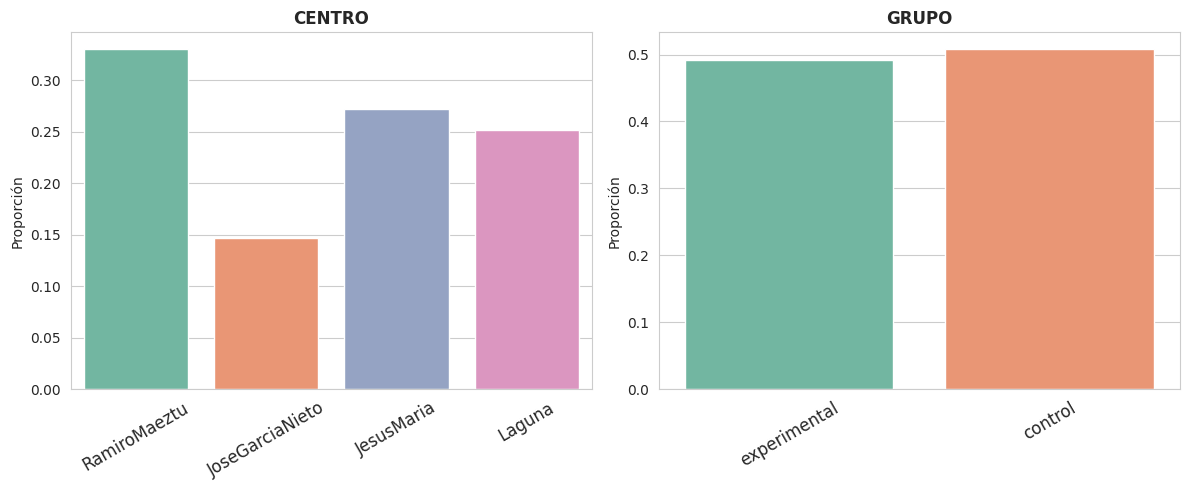

In [81]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = context_cols, 
    max_cols=3, 
    palette="Set2",
)

### Métricas de Rendimiento Forms

In [82]:
forms_cols = [col for col in forms_interactions_df.columns if 'puntuacion' in col]
forms_quant_cols = [col for col in forms_cols if col in quant_cols]
forms_cat_cols = [col for col in forms_cols if col in cat_cols]

#### TC-Hake

In [83]:
analysis_quant_cols = [col for col in forms_quant_cols if 'hake' in col]
analysis_cat_cols = [col for col in forms_cat_cols if 'hake' in col]

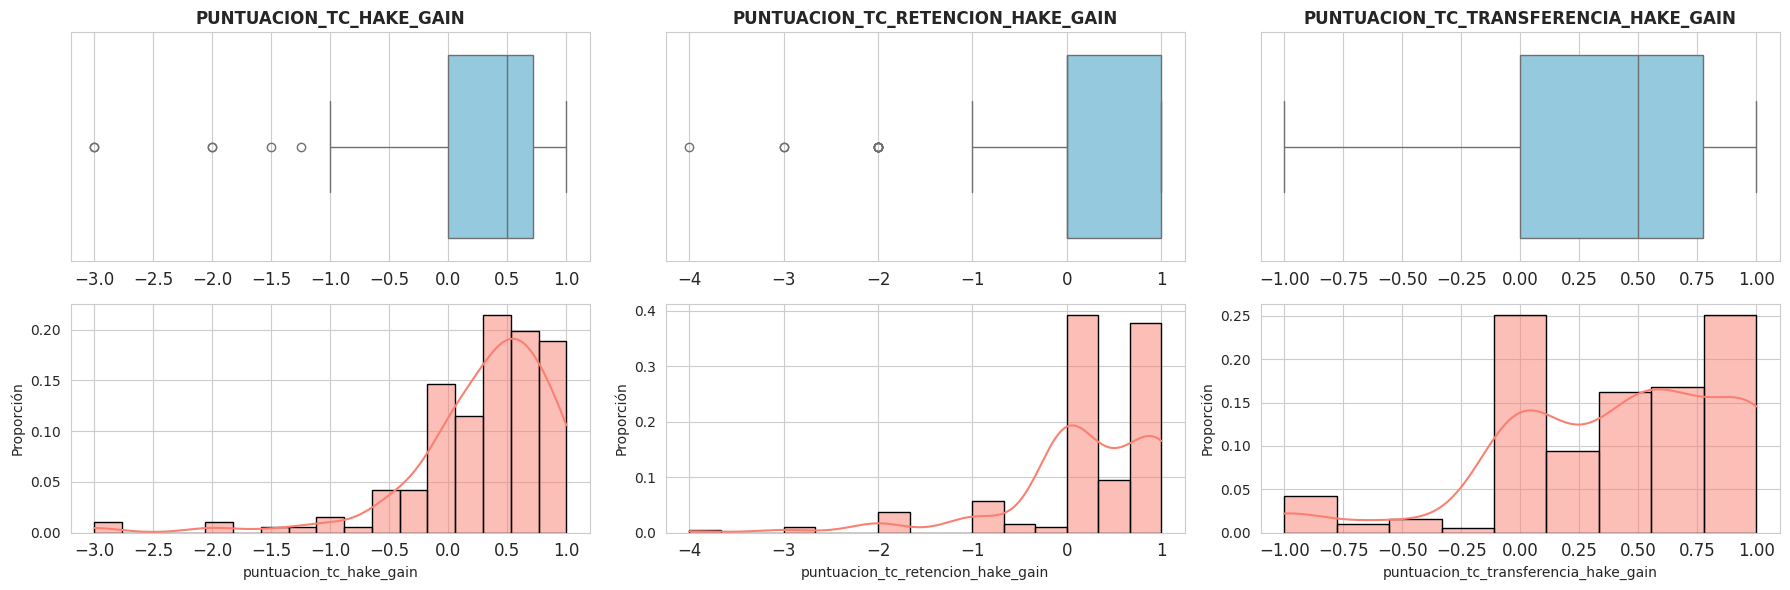

In [84]:
plot_quant_distribution(
    df = forms_interactions_df, 
    quant_cols = analysis_quant_cols, 
    max_cols=3, box_color="skyblue", hist_color="salmon"
)

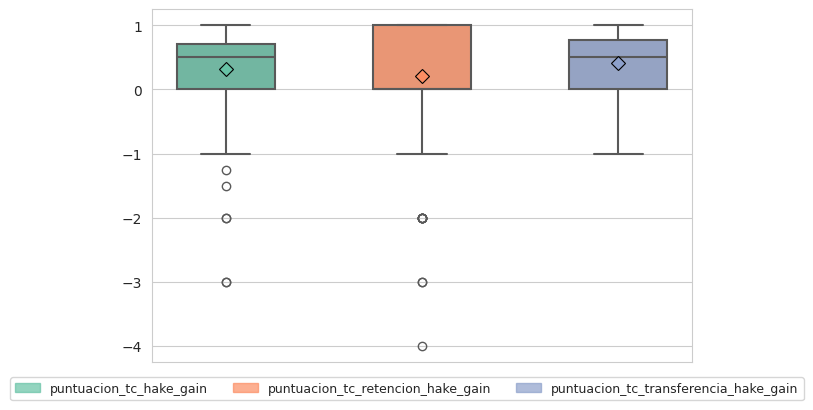

In [85]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        analysis_quant_cols
    ],
    showfliers=True,
    title=False,
    labelbottom=False
)

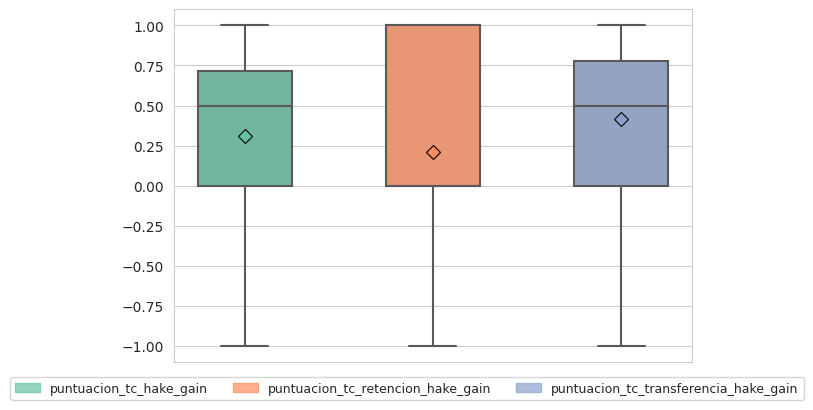

In [86]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        analysis_quant_cols
    ],
    showfliers=False,
    title=False,
    labelbottom=False
)

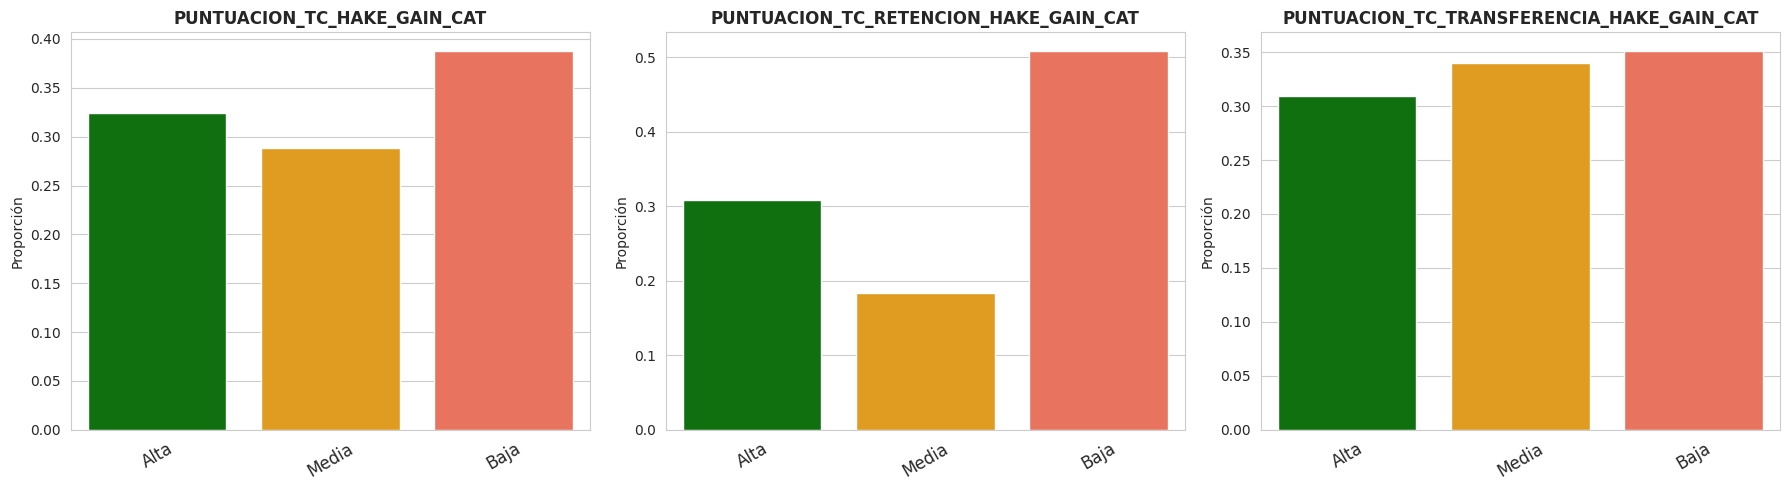

In [87]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = analysis_cat_cols, 
    order=['Alta', 'Media', 'Baja'],
    palette={'Alta': 'green', 'Media': 'orange', 'Baja': 'tomato'},
    max_cols=3
)

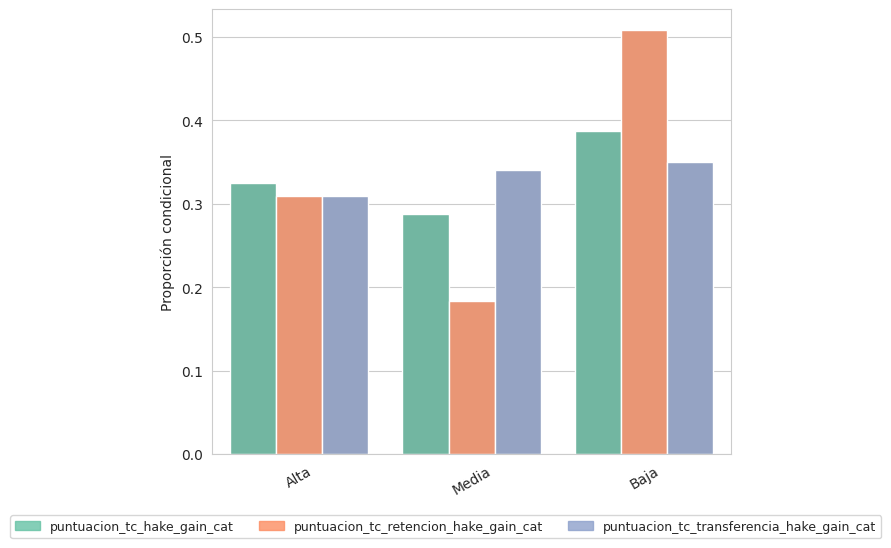

In [88]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        analysis_cat_cols
    ], 
    title=False,
    bbox_to_anchor=(0.5,-0.1),
    order=['Alta', 'Media', 'Baja']
)


#### TC-Pre

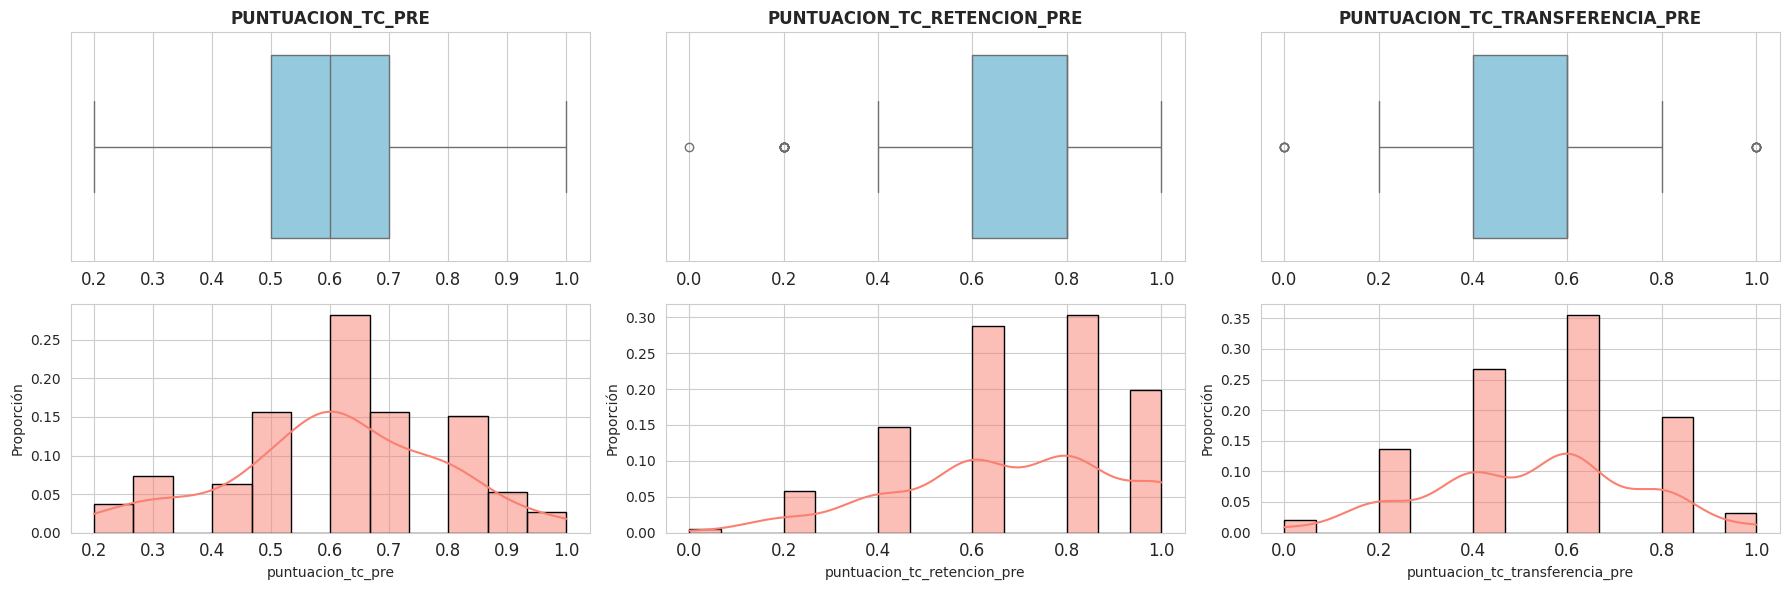

In [89]:
plot_quant_distribution(
    df = forms_interactions_df, 
    quant_cols = [col for col in forms_quant_cols if 'tc_' in col and 'hake' not in col and 'pre' in col], 
    max_cols=3, box_color="skyblue", hist_color="salmon"
)

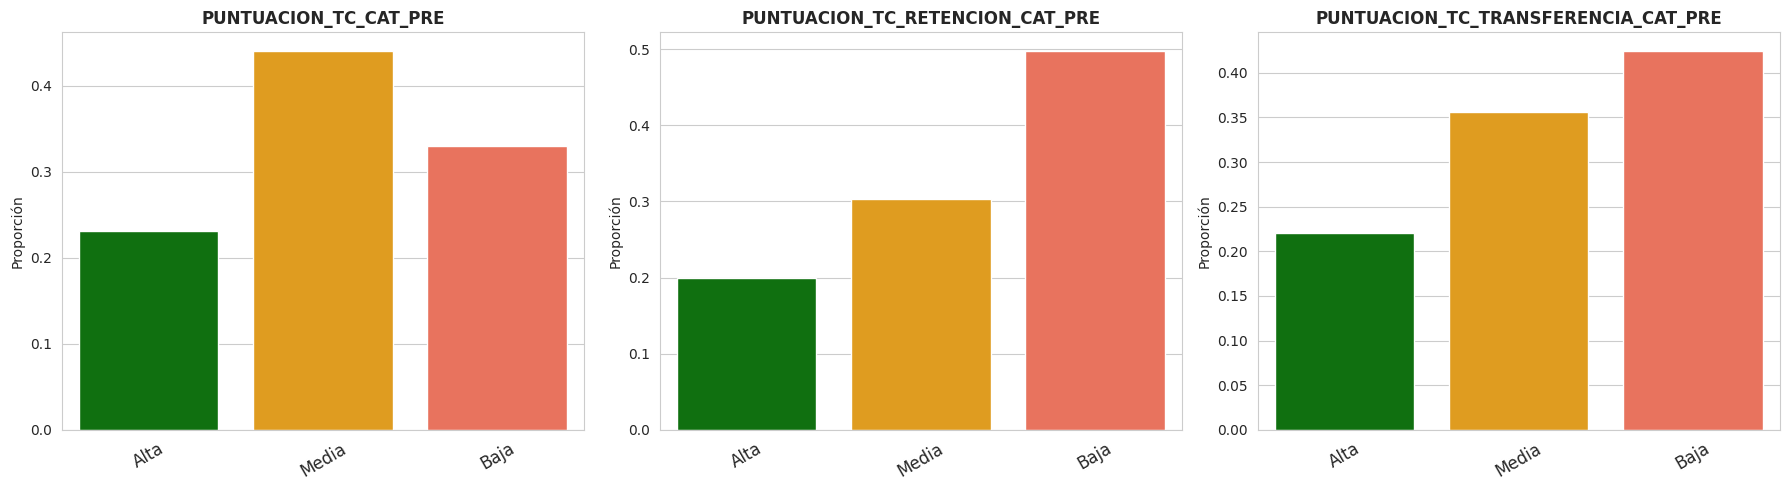

In [90]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = [col for col in forms_cat_cols if 'tc_' in col and 'hake' not in col and 'pre' in col], 
    max_cols=3, 
    order=['Alta', 'Media', 'Baja'],
    palette={'Alta': 'green', 'Media': 'orange', 'Baja': 'tomato'},
)

#### TC-Post

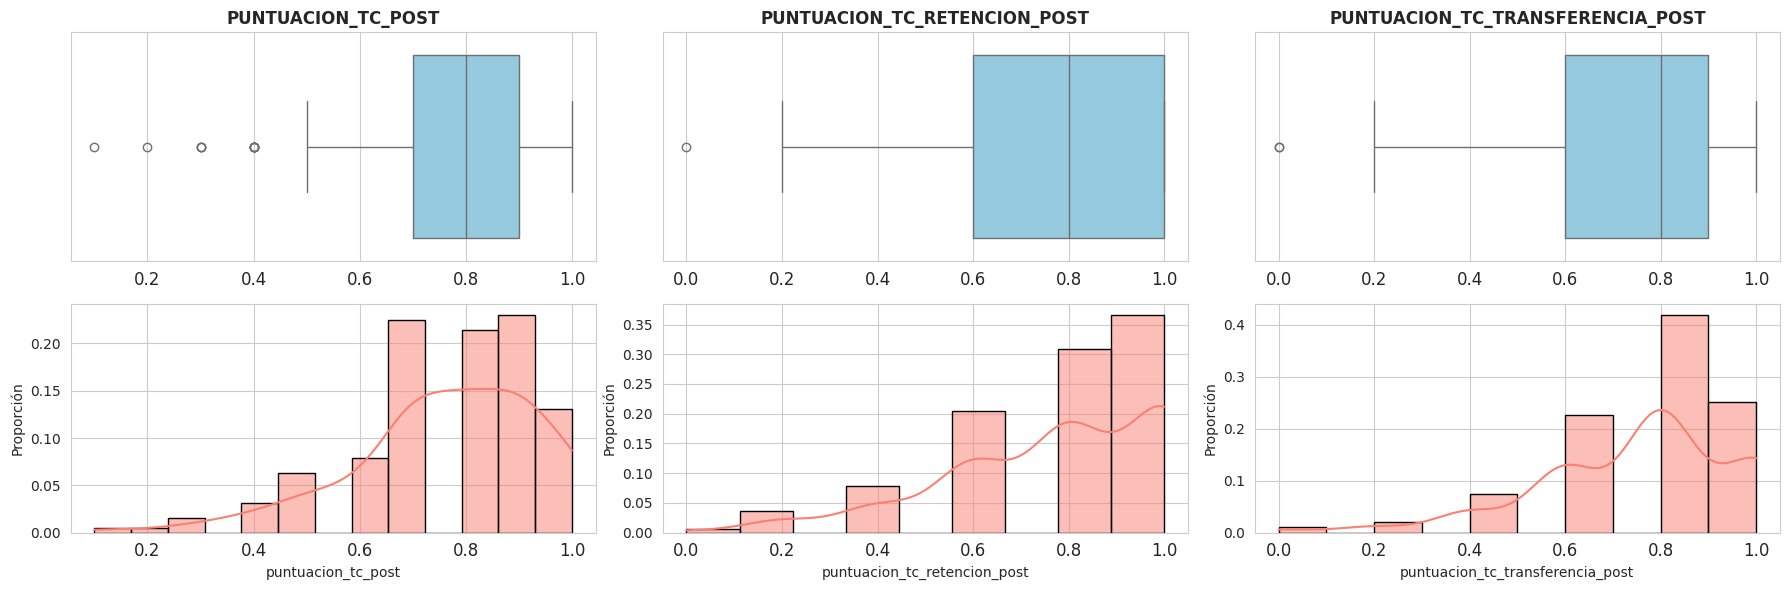

In [91]:
plot_quant_distribution(
    df = forms_interactions_df, 
    quant_cols = [col for col in forms_quant_cols if 'tc_' in col and 'hake' not in col and 'post' in col], 
    max_cols=3, box_color="skyblue", hist_color="salmon"
)

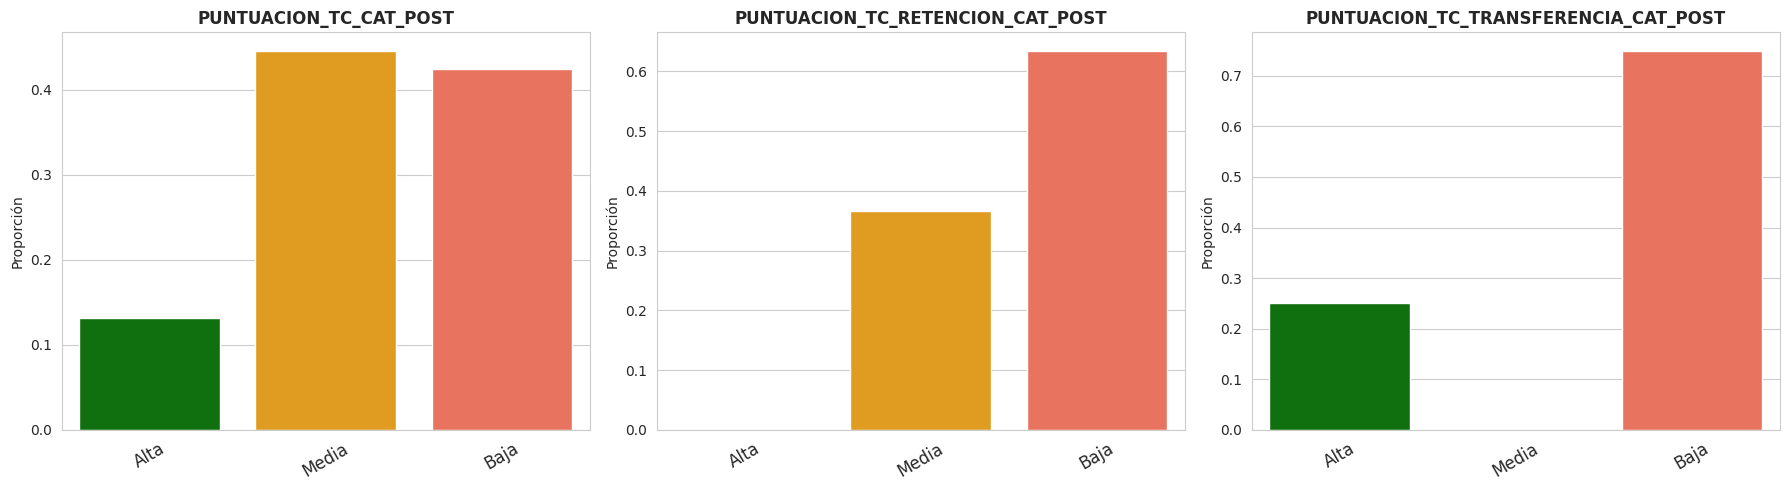

In [92]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = [col for col in forms_cat_cols if 'tc_' in col and 'hake' not in col and 'post' in col], 
    max_cols=3, 
    order=['Alta', 'Media', 'Baja'],
    palette={'Alta': 'green', 'Media': 'orange', 'Baja': 'tomato'},
)

#### TA-Pre-Post

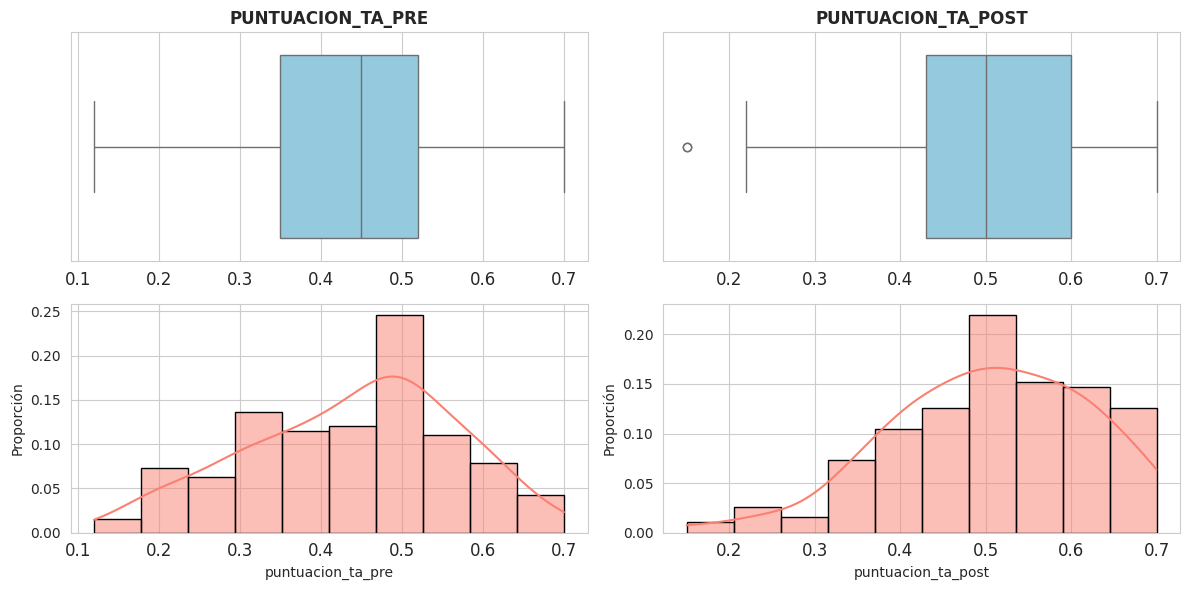

In [93]:
plot_quant_distribution(
    df = forms_interactions_df, 
    quant_cols = [col for col in forms_quant_cols if 'ta_' in col], 
    max_cols=3, box_color="skyblue", hist_color="salmon"
)

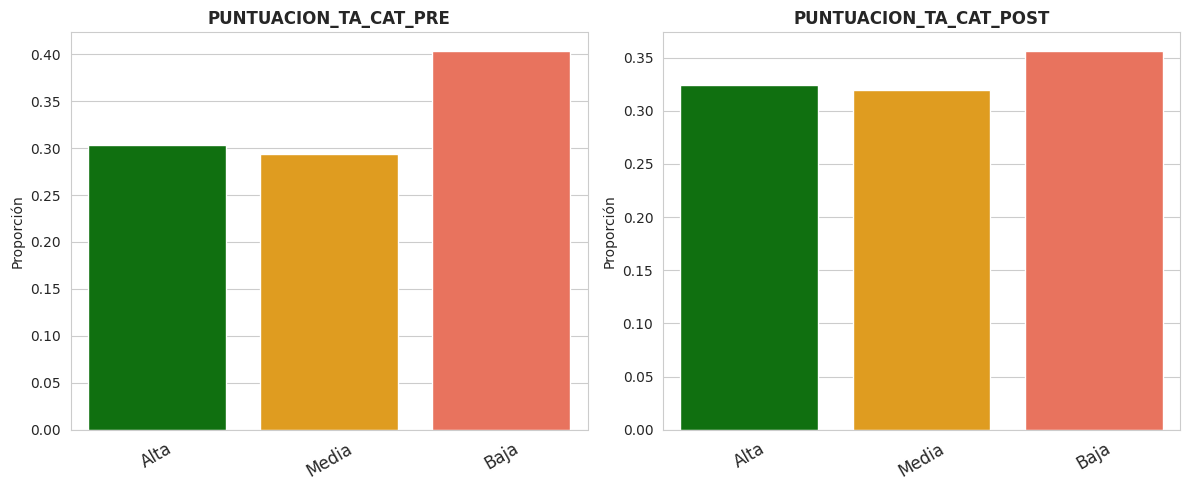

In [94]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = [col for col in forms_cat_cols if 'ta_' in col], 
    max_cols=3, 
    order=['Alta', 'Media', 'Baja'],
    palette={'Alta': 'green', 'Media': 'orange', 'Baja': 'tomato'},
)

#### TCC-Post

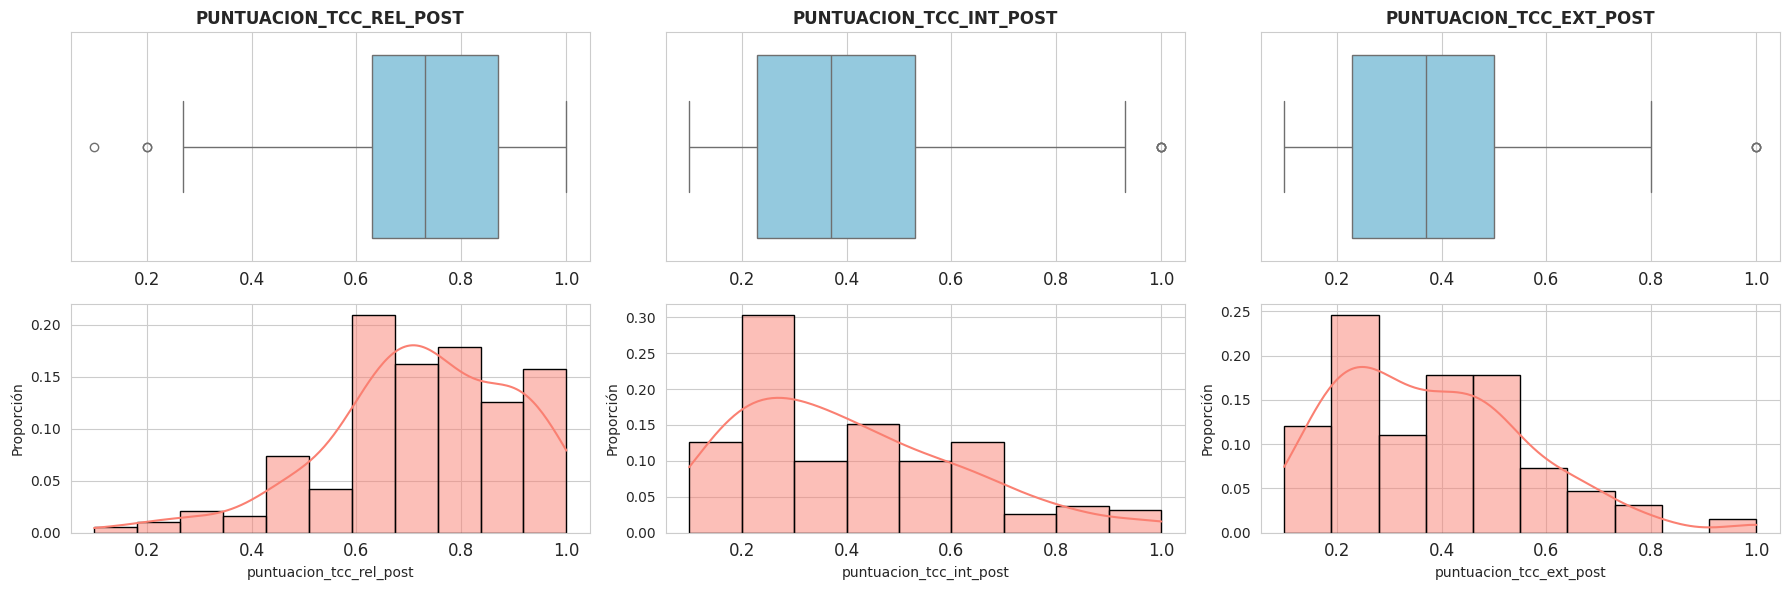

In [95]:
plot_quant_distribution(
    df = forms_interactions_df, 
    quant_cols = [col for col in forms_quant_cols if 'tcc_' in col], 
    max_cols=3, box_color="skyblue", hist_color="salmon"
)

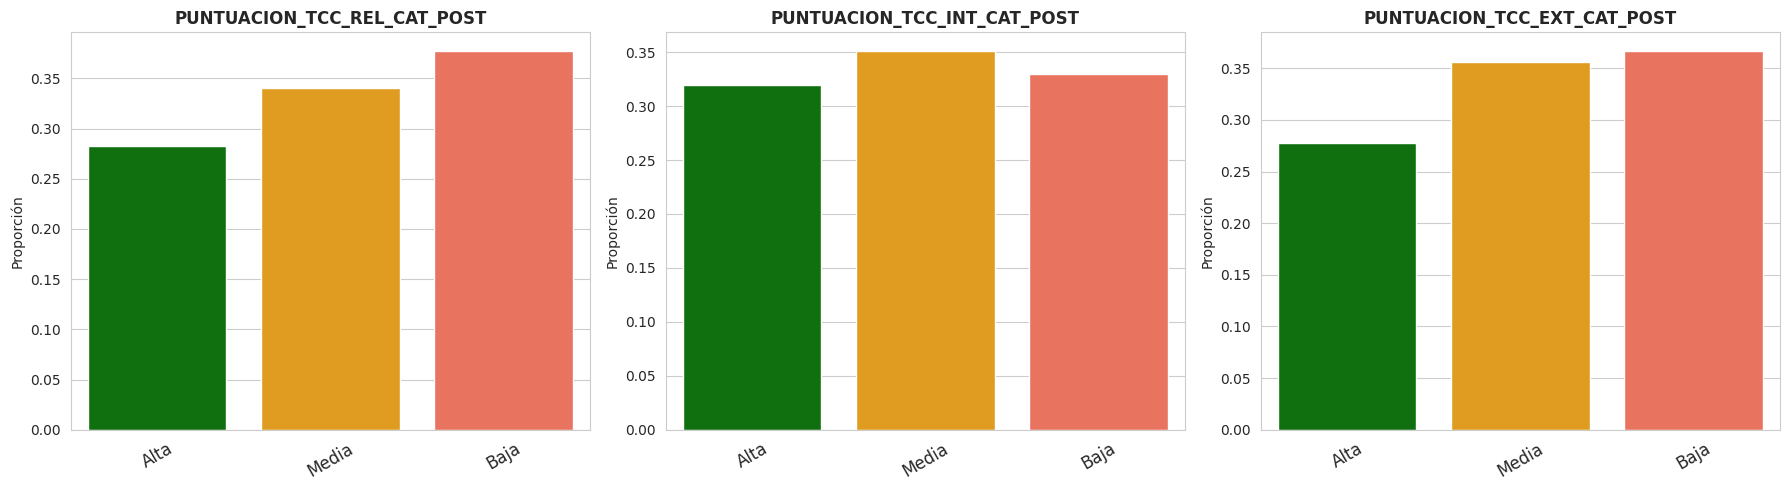

In [96]:
plot_cat_distribution(
    df = forms_interactions_df, 
    cat_cols = [col for col in forms_cat_cols if 'tcc_' in col], 
    max_cols=3, 
    order=['Alta', 'Media', 'Baja'],
    palette={'Alta': 'green', 'Media': 'orange', 'Baja': 'tomato'},
)

### Métricas Interacciones Herramienta

In [97]:
chats_cols = [col for col in forms_interactions_df.columns if col not in forms_cols + context_cols + ['id']]

chats_cat_cols = [col for col in chats_cols if col in cat_cols and col != 'grupo_segmented']
chats_quant_cols = [col for col in chats_cols if col in quant_cols]

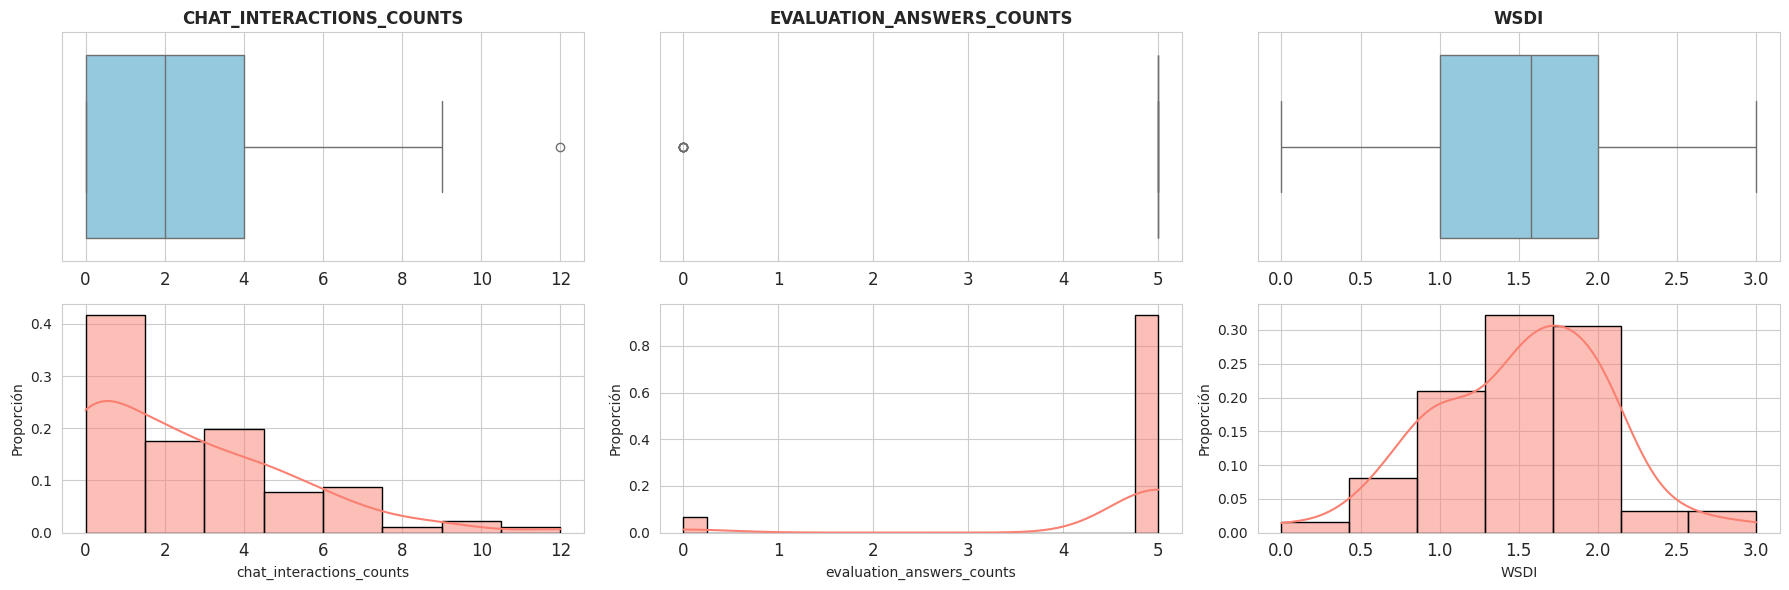

In [98]:
plot_quant_distribution(
    df = forms_interactions_df.filter(pl.col('grupo') == 'experimental'), 
    quant_cols = chats_quant_cols, 
    max_cols=3, box_color="skyblue", hist_color="salmon")


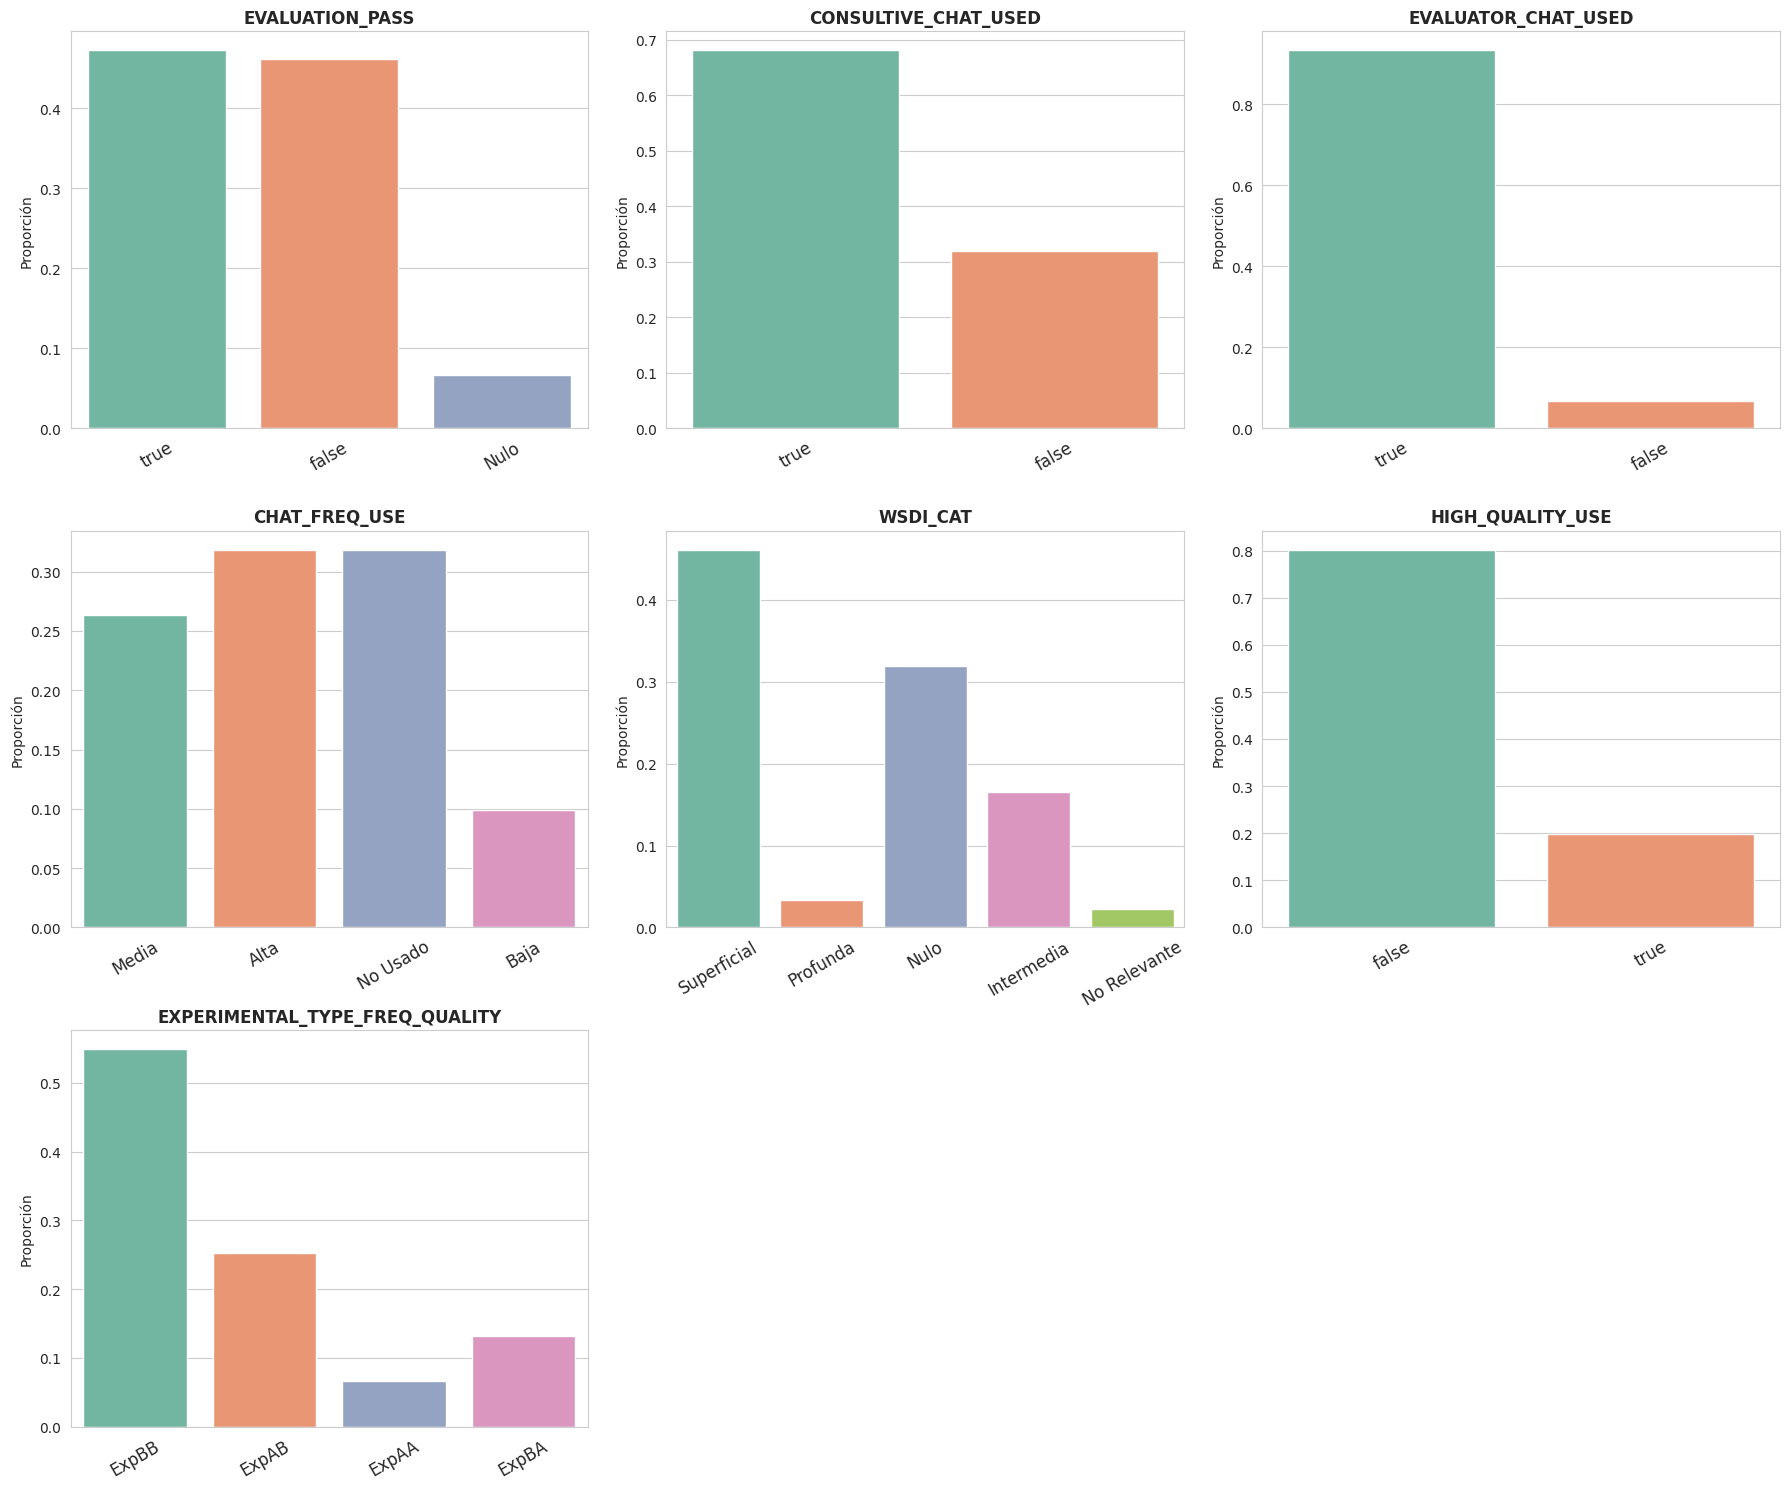

In [99]:
plot_cat_distribution(
    df = forms_interactions_df.filter(
        pl.col('grupo') == 'experimental',
        ~ pl.col('id').is_in(problematic_experimental_ids)
    ), 
    cat_cols = chats_cat_cols, 
    max_cols=3, 
    palette="Set2"
)

### Análisis Cruzado (Rendimiento Forms - Interacciones Herramienta)

#### TC-Hake por Grupos (Control vs Experimental)

In [100]:
for col in analysis_quant_cols:

    print("="*150)
    print(col.upper())
    print("="*150)
    
    display(
        group_stats(
            df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_experimental_ids)), 
            cols =  [col], 
            group_by = 'grupo'
        ).sort('grupo')
    )

PUNTUACION_TC_HAKE_GAIN


grupo,puntuacion_tc_hake_gain_mean,puntuacion_tc_hake_gain_std,puntuacion_tc_hake_gain_q25,puntuacion_tc_hake_gain_median,puntuacion_tc_hake_gain_q75,puntuacion_tc_hake_gain_min,puntuacion_tc_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""control""",0.405216,0.554484,0.167,0.5,0.75,-2.0,1.0
"""experimental""",0.248714,0.675574,0.0,0.4,0.6,-3.0,1.0


PUNTUACION_TC_RETENCION_HAKE_GAIN


grupo,puntuacion_tc_retencion_hake_gain_mean,puntuacion_tc_retencion_hake_gain_std,puntuacion_tc_retencion_hake_gain_q25,puntuacion_tc_retencion_hake_gain_median,puntuacion_tc_retencion_hake_gain_q75,puntuacion_tc_retencion_hake_gain_min,puntuacion_tc_retencion_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""control""",0.301577,0.80297,0.0,0.5,1.0,-4.0,1.0
"""experimental""",0.162099,0.811226,0.0,0.0,1.0,-3.0,1.0


PUNTUACION_TC_TRANSFERENCIA_HAKE_GAIN


grupo,puntuacion_tc_transferencia_hake_gain_mean,puntuacion_tc_transferencia_hake_gain_std,puntuacion_tc_transferencia_hake_gain_q25,puntuacion_tc_transferencia_hake_gain_median,puntuacion_tc_transferencia_hake_gain_q75,puntuacion_tc_transferencia_hake_gain_min,puntuacion_tc_transferencia_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""control""",0.481639,0.481089,0.0,0.5,1.0,-1.0,1.0
"""experimental""",0.365747,0.523519,0.0,0.5,0.75,-1.0,1.0


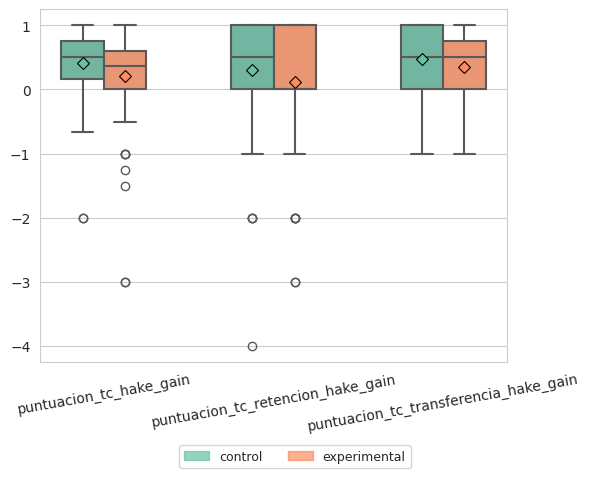

In [101]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        analysis_quant_cols
    ],
    group_by='grupo',
    showfliers=True,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

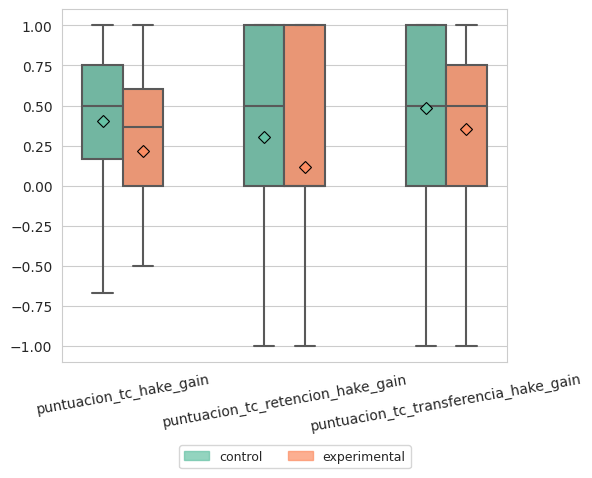

In [102]:
plot_quant_comparison(
    df = forms_interactions_df,
    comparisons = [
        analysis_quant_cols
    ],
    group_by='grupo',
    showfliers=False,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

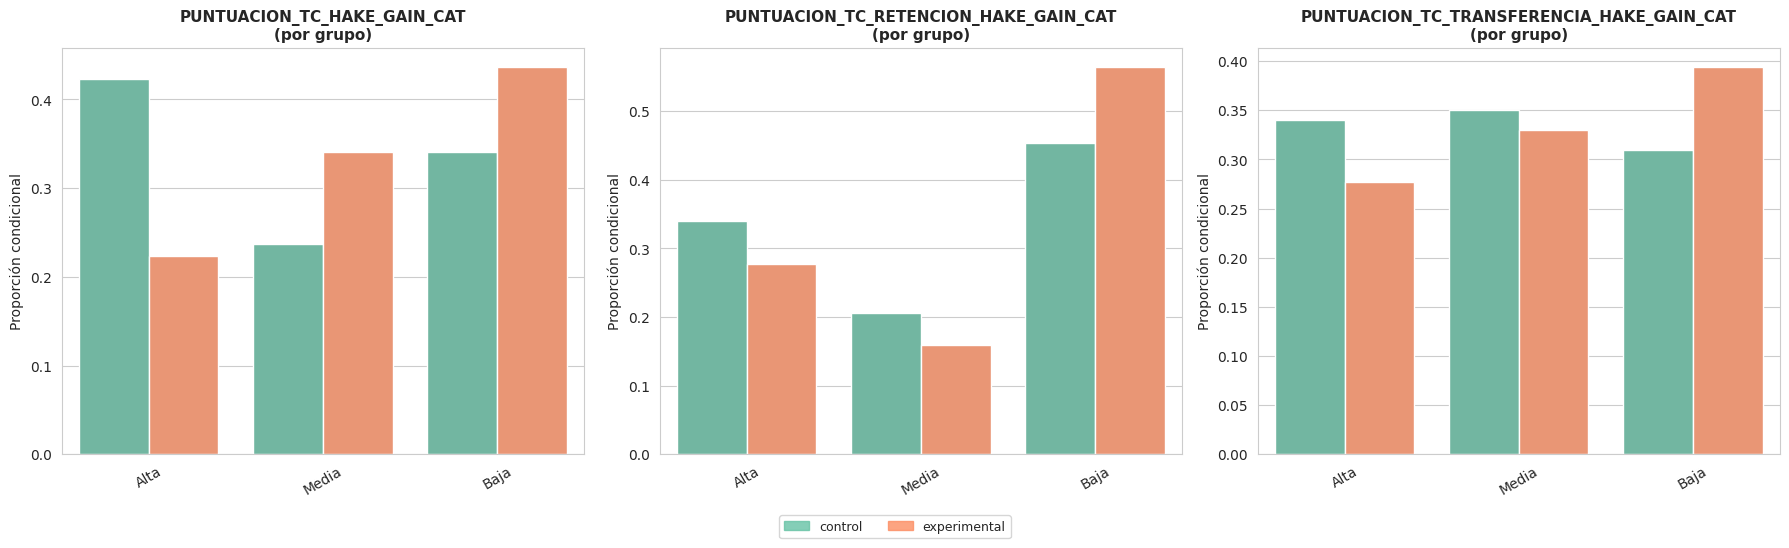

In [103]:
plot_cat_comparison(
    df=forms_interactions_df, 
    comparisons=[
        ['puntuacion_tc_hake_gain_cat'],
        ['puntuacion_tc_retencion_hake_gain_cat'],
        ['puntuacion_tc_transferencia_hake_gain_cat']
    ], 
    title=True,
    bbox_to_anchor=(0.5,-0.1),
    order=['Alta', 'Media', 'Baja'],
    group_by='grupo',
)


#### TC-Hake por Grupos Avanzado (Control vs Tipos de Experimental)

In [104]:
for col in analysis_quant_cols:

    print("="*150)
    print(col.upper())
    print("="*150)
    
    display(
        group_stats(
            df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_experimental_ids)), 
            cols =  [col], 
            group_by = 'grupo_segmented'
        ).sort('grupo_segmented')
    )

PUNTUACION_TC_HAKE_GAIN


grupo_segmented,puntuacion_tc_hake_gain_mean,puntuacion_tc_hake_gain_std,puntuacion_tc_hake_gain_q25,puntuacion_tc_hake_gain_median,puntuacion_tc_hake_gain_q75,puntuacion_tc_hake_gain_min,puntuacion_tc_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""ExpAA""",0.388833,0.779325,0.0,0.833,1.0,-1.0,1.0
"""ExpAB""",0.023478,1.059468,0.0,0.4,0.6,-3.0,1.0
"""ExpBA""",0.3875,0.291455,0.25,0.5,0.5,0.0,0.833
"""ExpBB""",0.3022,0.468425,0.0,0.333,0.6,-1.5,1.0
"""control""",0.405216,0.554484,0.167,0.5,0.75,-2.0,1.0


PUNTUACION_TC_RETENCION_HAKE_GAIN


grupo_segmented,puntuacion_tc_retencion_hake_gain_mean,puntuacion_tc_retencion_hake_gain_std,puntuacion_tc_retencion_hake_gain_q25,puntuacion_tc_retencion_hake_gain_median,puntuacion_tc_retencion_hake_gain_q75,puntuacion_tc_retencion_hake_gain_min,puntuacion_tc_retencion_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""ExpAA""",0.111167,1.572943,0.0,1.0,1.0,-3.0,1.0
"""ExpAB""",0.079696,0.789557,0.0,0.0,0.5,-2.0,1.0
"""ExpBA""",0.388917,0.648762,0.0,0.667,1.0,-1.0,1.0
"""ExpBB""",0.15168,0.752112,0.0,0.0,0.75,-2.0,1.0
"""control""",0.301577,0.80297,0.0,0.5,1.0,-4.0,1.0


PUNTUACION_TC_TRANSFERENCIA_HAKE_GAIN


grupo_segmented,puntuacion_tc_transferencia_hake_gain_mean,puntuacion_tc_transferencia_hake_gain_std,puntuacion_tc_transferencia_hake_gain_q25,puntuacion_tc_transferencia_hake_gain_median,puntuacion_tc_transferencia_hake_gain_q75,puntuacion_tc_transferencia_hake_gain_min,puntuacion_tc_transferencia_hake_gain_max
str,f64,f64,f64,f64,f64,f64,f64
"""ExpAA""",0.361167,0.561826,0.0,0.5,1.0,-0.333,1.0
"""ExpAB""",0.280391,0.666262,0.0,0.5,0.75,-1.0,1.0
"""ExpBA""",0.354167,0.289018,0.0,0.5,0.5,0.0,0.75
"""ExpBB""",0.40834,0.49782,0.0,0.5,0.75,-1.0,1.0
"""control""",0.481639,0.481089,0.0,0.5,1.0,-1.0,1.0


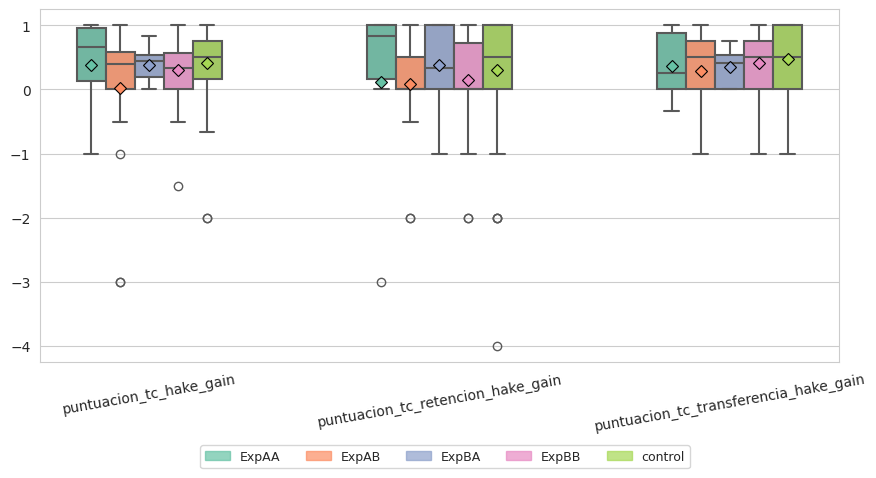

In [105]:
plot_quant_comparison(
    figsize = (9,4),
    df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_experimental_ids)),
    comparisons = [
        analysis_quant_cols
    ],
    group_by='grupo_segmented',
    showfliers=True,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

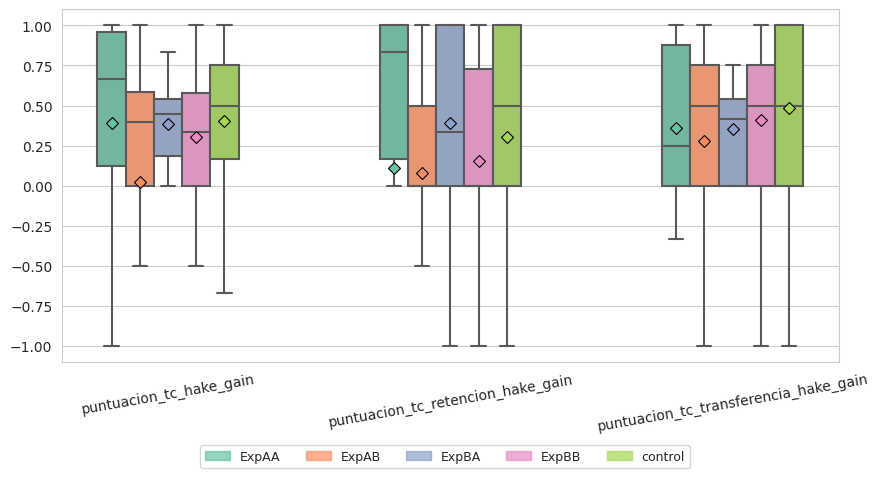

In [129]:
plot_quant_comparison(
    figsize = (9,4),
    df = forms_interactions_df.filter(~ pl.col('id').is_in(problematic_experimental_ids)),
    comparisons = [
        analysis_quant_cols
    ],
    group_by='grupo_segmented',
    showfliers=False,
    title=False,
    labelbottom=True,
    xlabel_rotation=10,
    bbox_to_anchor=(0.5, -0.2)
)

In [133]:
forms_interactions_df

id,centro,grupo,puntuacion_tc_hake_gain,puntuacion_tc_retencion_hake_gain,puntuacion_tc_transferencia_hake_gain,puntuacion_tc_hake_gain_cat,puntuacion_tc_retencion_hake_gain_cat,puntuacion_tc_transferencia_hake_gain_cat,puntuacion_tc_pre,puntuacion_ta_pre,puntuacion_tc_retencion_pre,puntuacion_tc_transferencia_pre,puntuacion_tc_cat_pre,puntuacion_ta_cat_pre,puntuacion_tc_retencion_cat_pre,puntuacion_tc_transferencia_cat_pre,puntuacion_tc_post,puntuacion_ta_post,puntuacion_tc_retencion_post,puntuacion_tc_transferencia_post,puntuacion_tc_cat_post,puntuacion_ta_cat_post,puntuacion_tc_retencion_cat_post,puntuacion_tc_transferencia_cat_post,puntuacion_tcc_rel_post,puntuacion_tcc_int_post,puntuacion_tcc_ext_post,puntuacion_tcc_rel_cat_post,puntuacion_tcc_int_cat_post,puntuacion_tcc_ext_cat_post,chat_interactions_counts,evaluation_answers_counts,evaluation_pass,consultive_chat_used,evaluator_chat_used,chat_freq_use,WSDI,WSDI_cat,high_quality_use,experimental_type_freq_quality,grupo_segmented
str,str,str,f64,f64,f64,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,str,str,str,i64,i64,bool,bool,bool,str,f64,str,bool,str,str
"""RamiroMaeztu-ks0""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,"""Alta""","""Alta""","""Alta""",0.6,0.2,0.8,0.4,"""Media""","""Baja""","""Media""","""Baja""",1.0,0.4,1.0,1.0,"""Alta""","""Baja""","""Media""","""Alta""",0.8,0.43,0.27,"""Media""","""Media""","""Baja""",2,5,true,true,true,"""Media""",1.5,"""Superficial""",false,"""ExpBB""","""ExpBB"""
"""RamiroMaeztu-pu9""","""RamiroMaeztu""","""experimental""",1.0,0.0,1.0,"""Alta""","""Baja""","""Alta""",0.8,0.48,1.0,0.6,"""Alta""","""Media""","""Alta""","""Media""",1.0,0.55,1.0,1.0,"""Alta""","""Media""","""Media""","""Alta""",0.2,0.4,0.27,"""Baja""","""Media""","""Baja""",8,5,false,true,true,"""Alta""",1.625,"""Superficial""",false,"""ExpAB""","""ExpAB"""
"""RamiroMaeztu-8jb""","""RamiroMaeztu""","""experimental""",1.0,1.0,1.0,"""Alta""","""Alta""","""Alta""",0.6,0.45,0.6,0.6,"""Media""","""Media""","""Baja""","""Media""",1.0,0.4,1.0,1.0,"""Alta""","""Baja""","""Media""","""Alta""",0.57,0.6,0.47,"""Baja""","""Alta""","""Media""",7,5,true,true,true,"""Alta""",2.571429,"""Profunda""",true,"""ExpAA""","""ExpAA"""
"""RamiroMaeztu-x5e""","""RamiroMaeztu""","""experimental""",0.0,-2.0,0.667,"""Baja""","""Baja""","""Media""",0.6,0.7,0.8,0.4,"""Media""","""Alta""","""Media""","""Baja""",0.6,0.43,0.4,0.8,"""Baja""","""Baja""","""Baja""","""Baja""",0.63,0.53,0.63,"""Baja""","""Alta""","""Alta""",0,5,false,false,true,"""No Usado""",null,null,false,"""ExpBB""","""ExpBB"""
"""RamiroMaeztu-80a""","""RamiroMaeztu""","""experimental""",0.5,0.0,0.5,"""Media""","""Baja""","""Media""",0.8,0.52,1.0,0.6,"""Alta""","""Alta""","""Alta""","""Media""",0.9,0.6,1.0,0.8,"""Media""","""Alta""","""Media""","""Baja""",0.9,0.3,0.27,"""Alta""","""Media""","""Baja""",0,5,false,false,true,"""No Usado""",null,null,false,"""ExpBB""","""ExpBB"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Laguna-r45""","""Laguna""","""experimental""",0.0,-1.0,0.5,"""Baja""","""Baja""","""Media""",0.7,0.35,0.8,0.6,"""Media""","""Baja""","""Media""","""Media""",0.7,0.6,0.6,0.8,"""Baja""","""Alta""","""Baja""","""Baja""",0.63,0.47,0.43,"""Baja""","""Media""","""Media""",3,5,true,true,true,"""Media""",1.333333,"""Superficial""",false,"""ExpBB""","""ExpBB"""
"""Laguna-lqw""","""Laguna""","""experimental""",0.4,0.5,0.333,"""Media""","""Media""","""Media""",0.5,0.52,0.6,0.4,"""Baja""","""Alta""","""Baja""","""Baja""",0.7,0.6,0.8,0.6,"""Baja""","""Alta""","""Baja""","""Baja""",0.93,0.53,0.2,"""Alta""","""Alta""","""Baja""",2,5,false,true,true,"""Media""",1.0,"""Superficial""",false,"""ExpBB""","""ExpBB"""
"""Laguna-chn""","""Laguna""","""experimental""",0.2,-2.0,0.75,"""Baja""","""Baja""","""Alta""",0.5,0.52,0.8,0.2,"""Baja""","""Alta""","""Media""","""Baja""",0.6,0.58,0.4,0.8,"""Baja""","""Alta""","""Baja""","""Baja""",0.93,0.27,0.33,""

CENTRO

── CONDICIÓN: JOSEGARCIANIETO ──

n = 28


grupo_segmented,count,prop
str,u32,f64
"""ExpBA""",2,0.07
"""ExpAB""",6,0.21
"""control""",14,0.5
"""ExpBB""",6,0.21


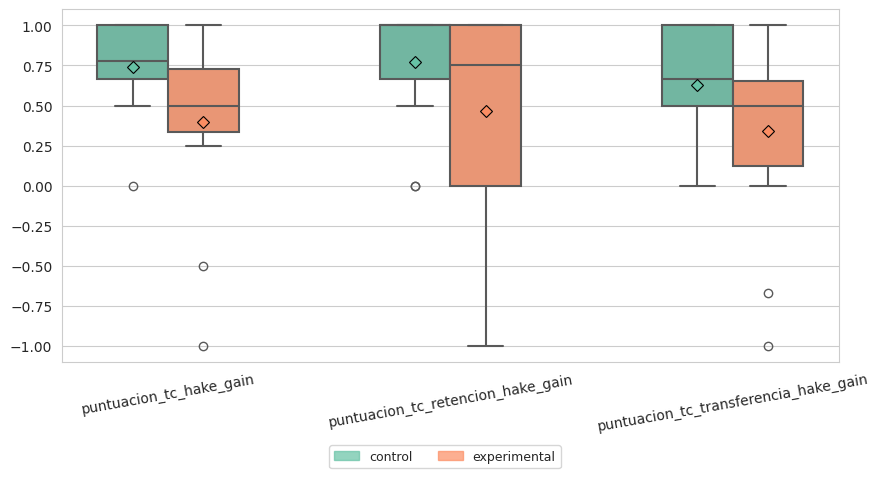

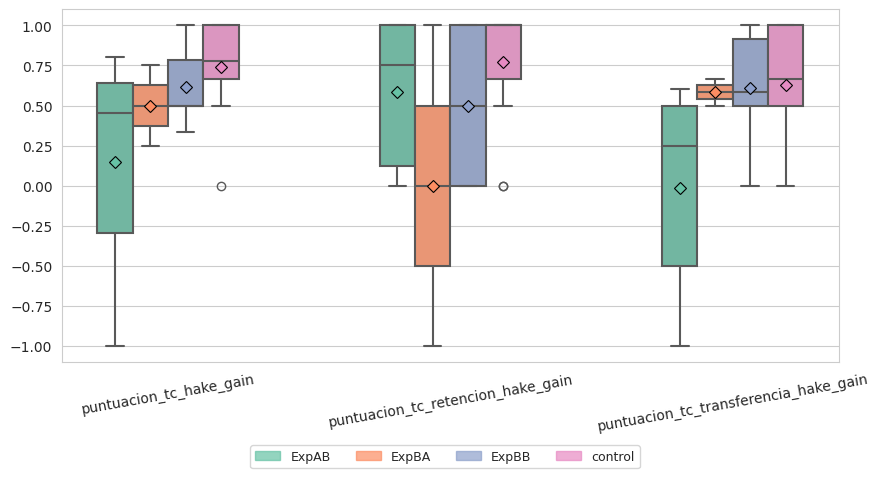


── CONDICIÓN: JESUSMARIA ──

n = 49


grupo_segmented,count,prop
str,u32,f64
"""ExpBA""",7,0.14
"""ExpAA""",3,0.06
"""ExpBB""",5,0.1
"""ExpAB""",7,0.14
"""control""",27,0.55


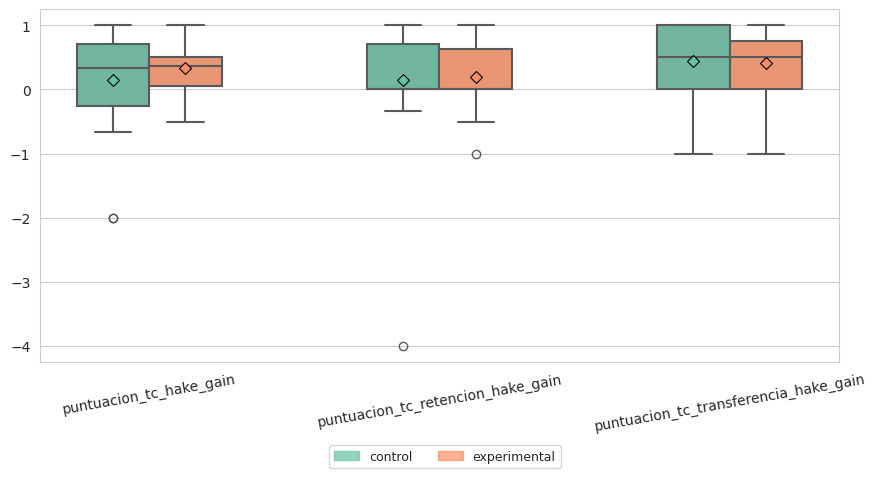

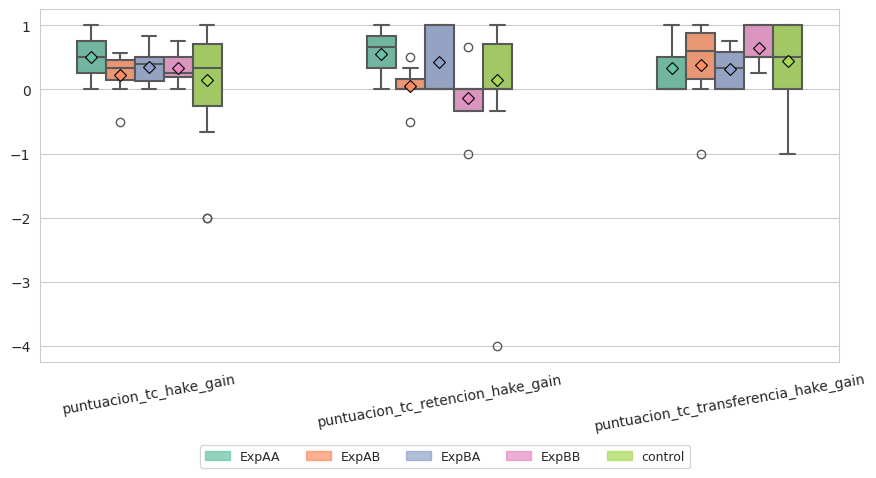


── CONDICIÓN: RAMIROMAEZTU ──

n = 63


grupo_segmented,count,prop
str,u32,f64
"""ExpBB""",24,0.38
"""ExpAB""",5,0.08
"""ExpAA""",1,0.02
"""ExpBA""",2,0.03
"""control""",31,0.49


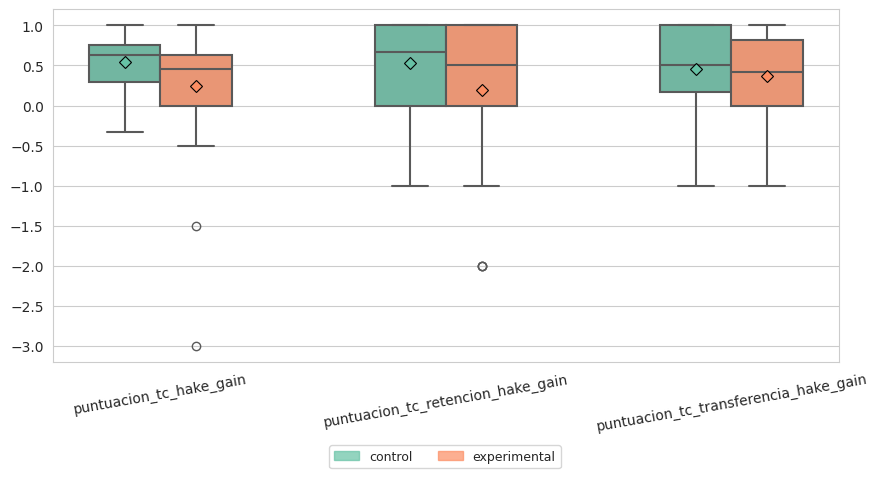

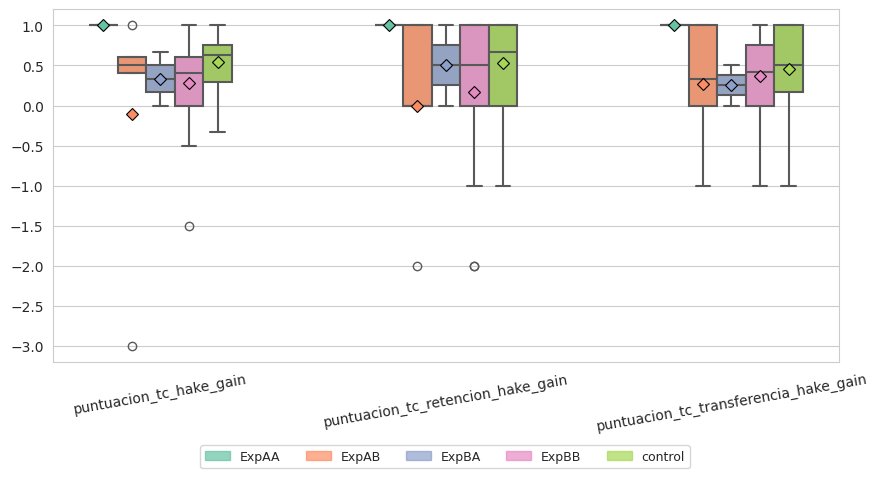


── CONDICIÓN: LAGUNA ──

n = 48


grupo_segmented,count,prop
str,u32,f64
"""ExpBB""",15,0.31
"""ExpAB""",5,0.1
"""ExpAA""",2,0.04
"""control""",25,0.52
"""ExpBA""",1,0.02


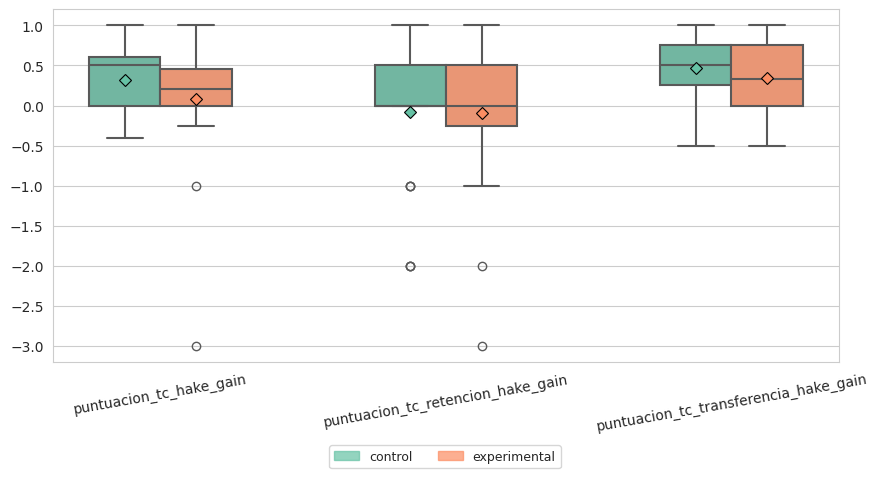

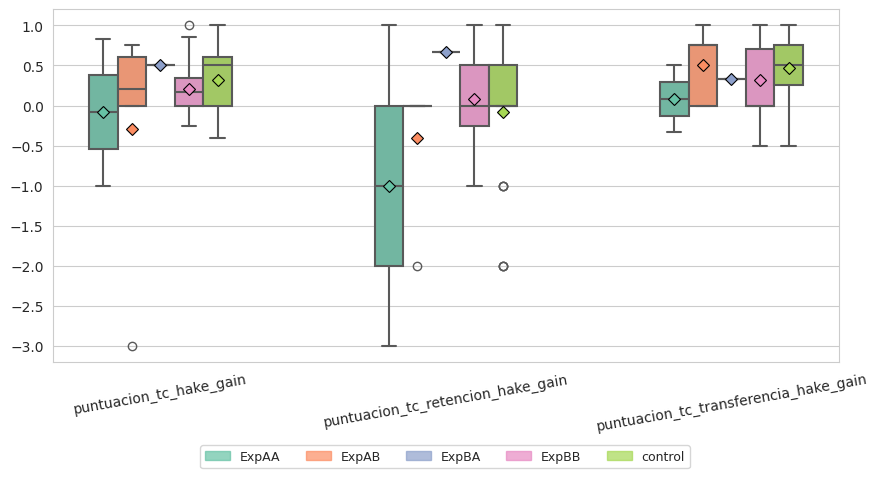

PUNTUACION_TC_HAKE_GAIN_CAT

── CONDICIÓN: ALTA ──

n = 62


grupo_segmented,count,prop
str,u32,f64
"""ExpBB""",11,0.18
"""control""",41,0.66
"""ExpBA""",3,0.05
"""ExpAB""",4,0.06
"""ExpAA""",3,0.05


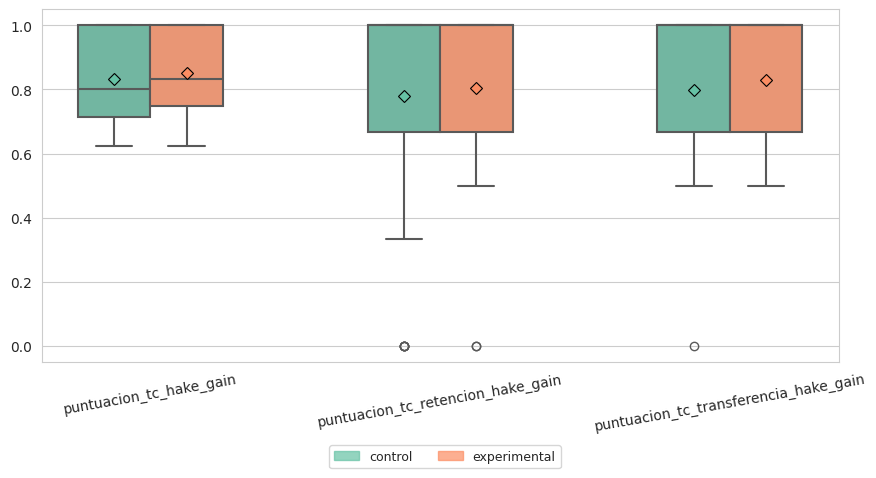

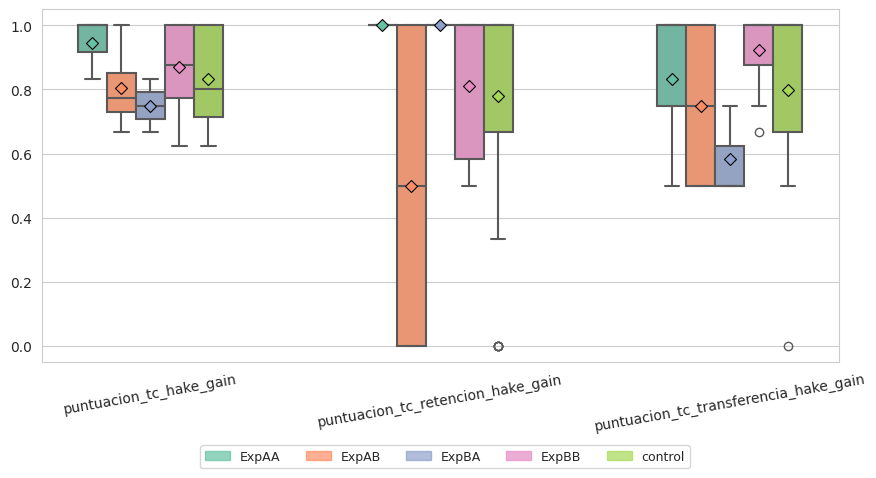


── CONDICIÓN: MEDIA ──

n = 55


grupo_segmented,count,prop
str,u32,f64
"""ExpBB""",16,0.29
"""ExpAA""",1,0.02
"""ExpAB""",11,0.2
"""control""",23,0.42
"""ExpBA""",4,0.07


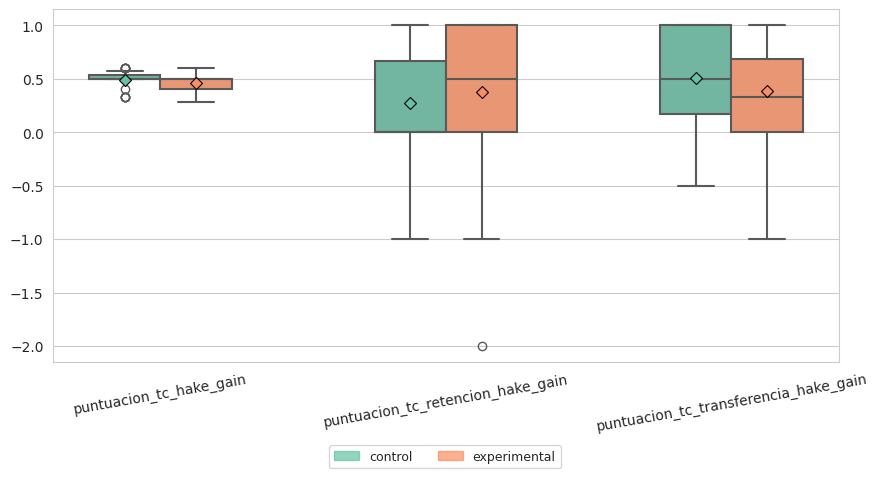

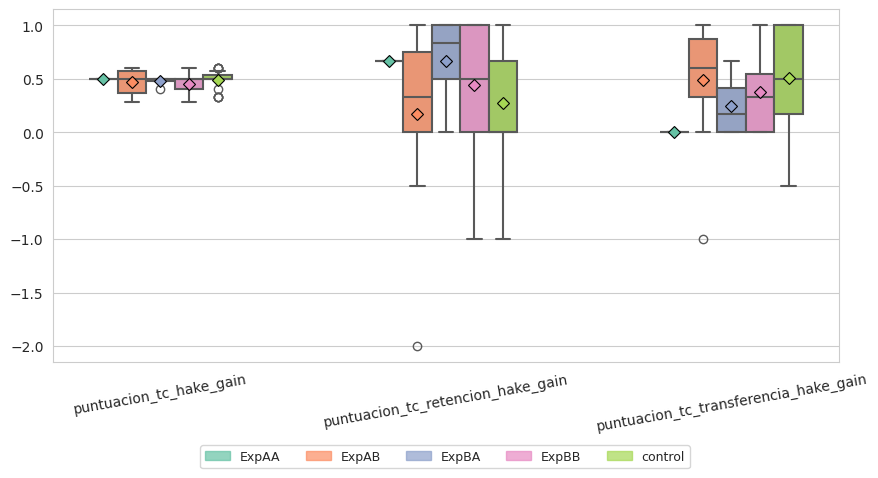


── CONDICIÓN: BAJA ──

n = 71


grupo_segmented,count,prop
str,u32,f64
"""ExpAA""",2,0.03
"""ExpAB""",8,0.11
"""ExpBA""",5,0.07
"""control""",33,0.46
"""ExpBB""",23,0.32


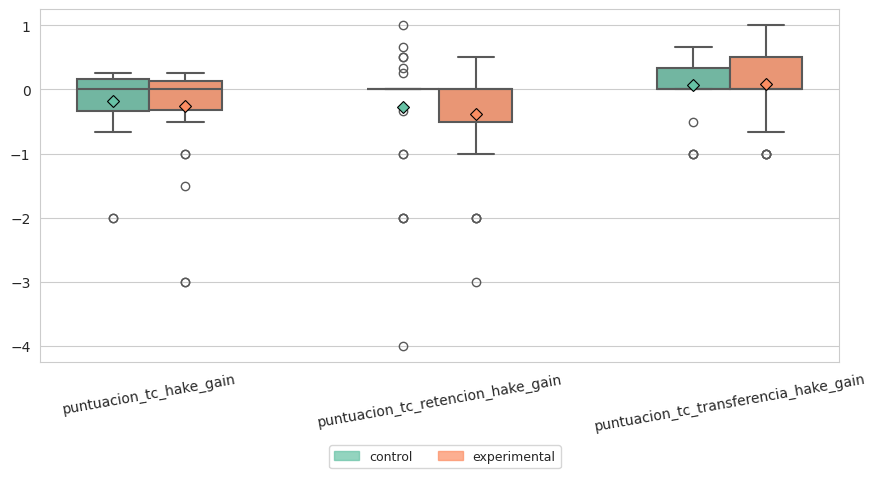

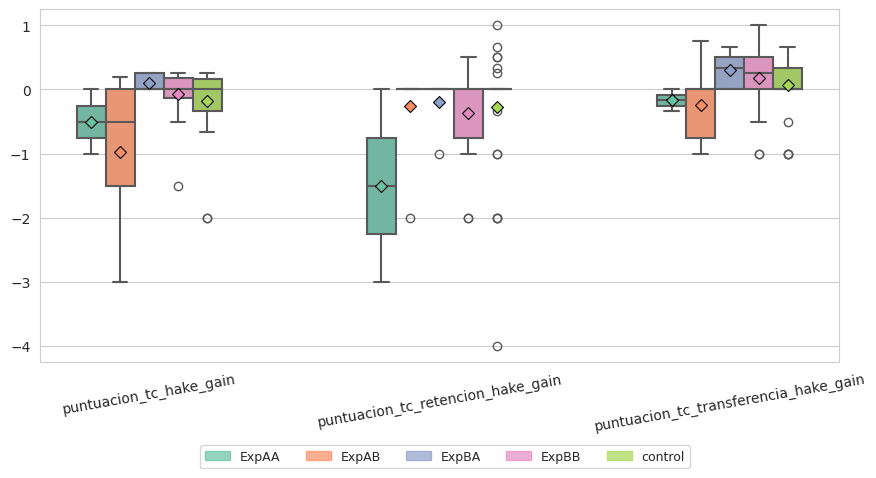

PUNTUACION_TCC_INT_CAT_POST

── CONDICIÓN: MEDIA ──

n = 67


grupo_segmented,count,prop
str,u32,f64
"""ExpAB""",10,0.15
"""ExpBA""",3,0.04
"""control""",36,0.54
"""ExpBB""",18,0.27


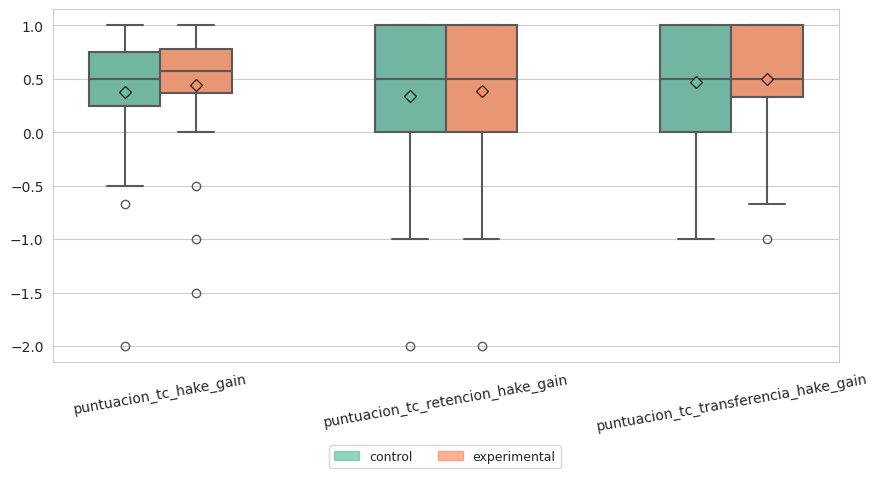

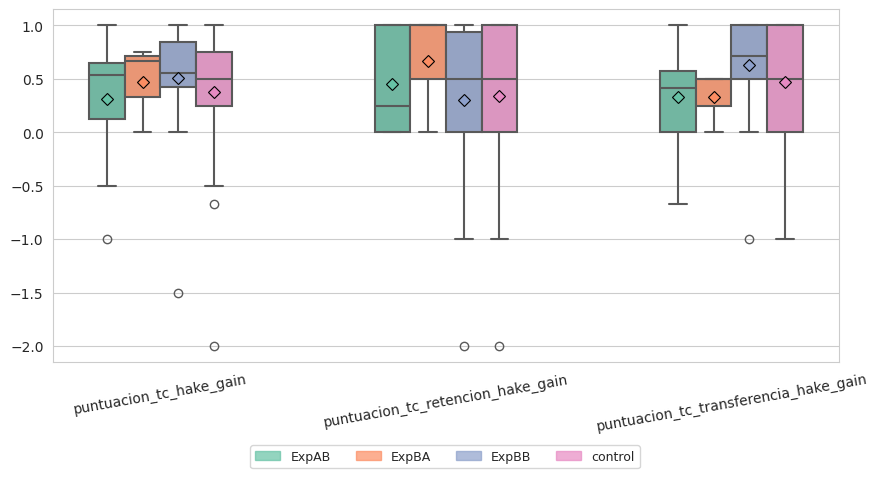


── CONDICIÓN: BAJA ──

n = 62


grupo_segmented,count,prop
str,u32,f64
"""ExpAA""",2,0.03
"""ExpBA""",4,0.06
"""ExpAB""",6,0.1
"""control""",37,0.6
"""ExpBB""",13,0.21


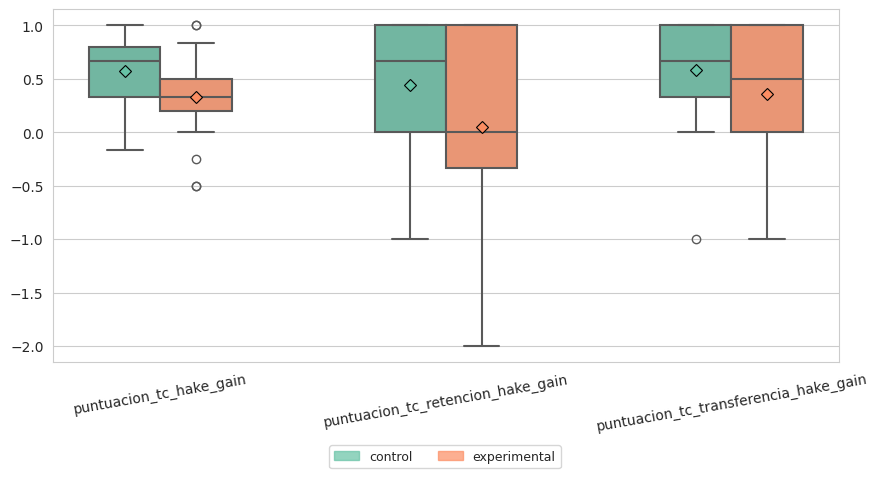

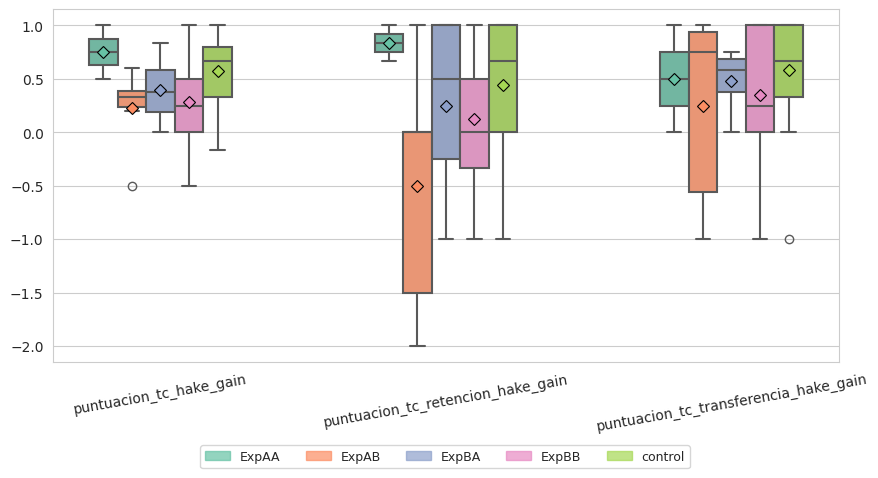


── CONDICIÓN: ALTA ──

n = 59


grupo_segmented,count,prop
str,u32,f64
"""ExpBA""",5,0.08
"""ExpAB""",7,0.12
"""control""",24,0.41
"""ExpAA""",4,0.07
"""ExpBB""",19,0.32


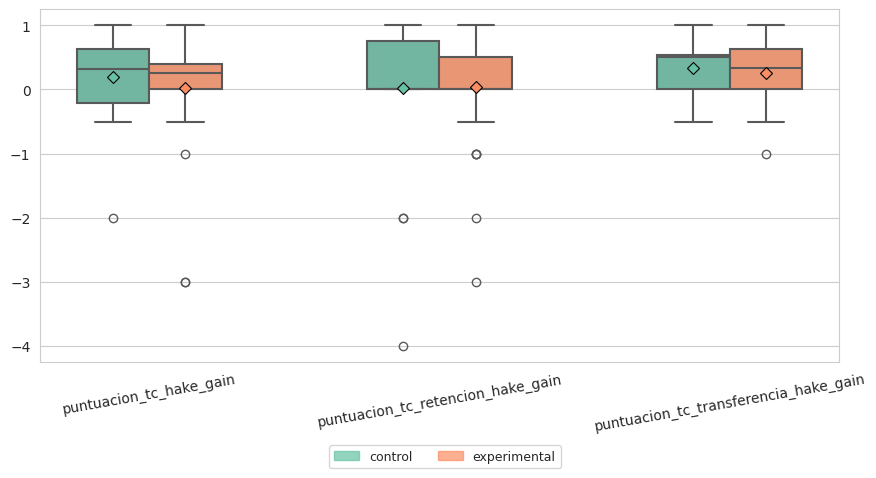

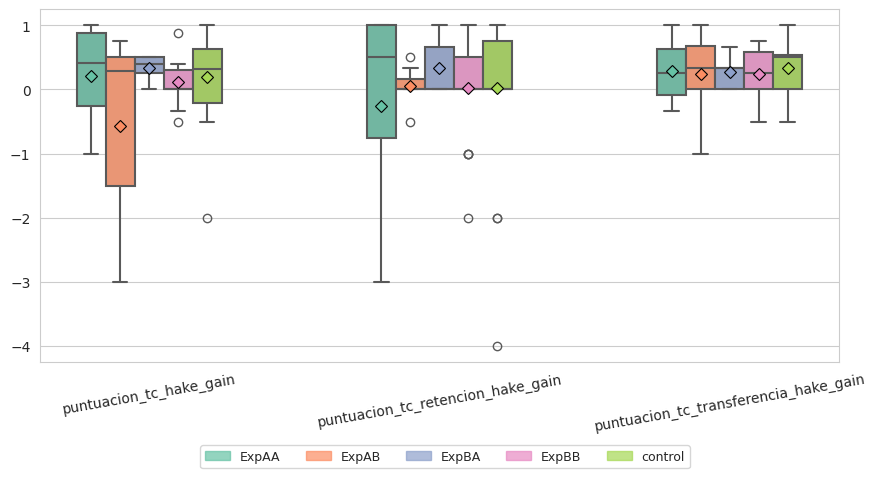

PUNTUACION_TCC_EXT_CAT_POST

── CONDICIÓN: MEDIA ──

n = 68


grupo_segmented,count,prop
str,u32,f64
"""ExpBA""",3,0.04
"""ExpAB""",11,0.16
"""ExpAA""",1,0.01
"""ExpBB""",18,0.26
"""control""",35,0.51


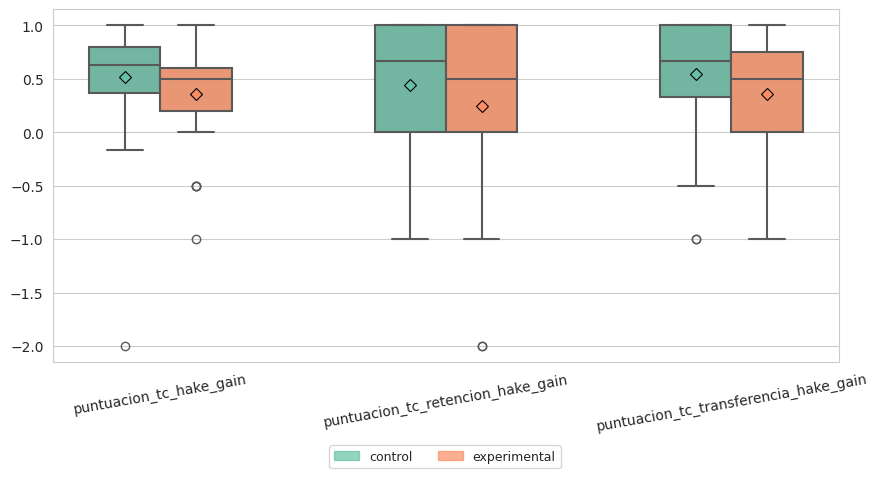

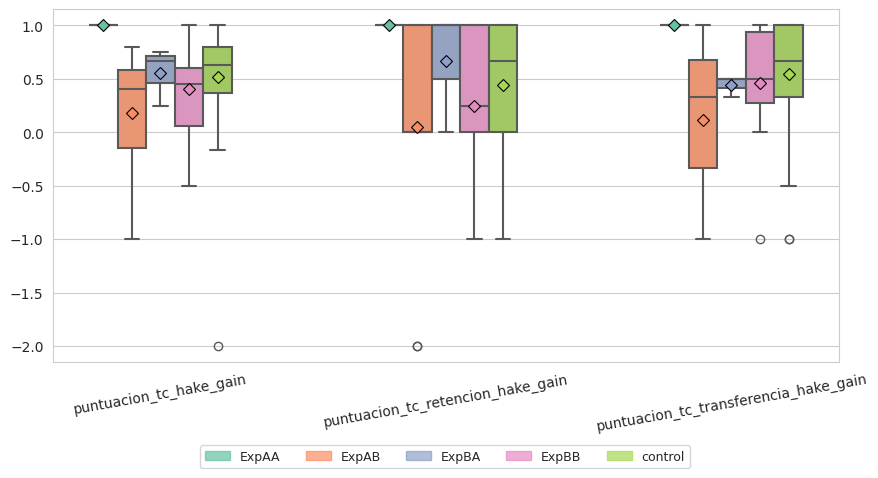


── CONDICIÓN: ALTA ──

n = 51


grupo_segmented,count,prop
str,u32,f64
"""control""",17,0.33
"""ExpBB""",18,0.35
"""ExpBA""",6,0.12
"""ExpAB""",6,0.12
"""ExpAA""",4,0.08


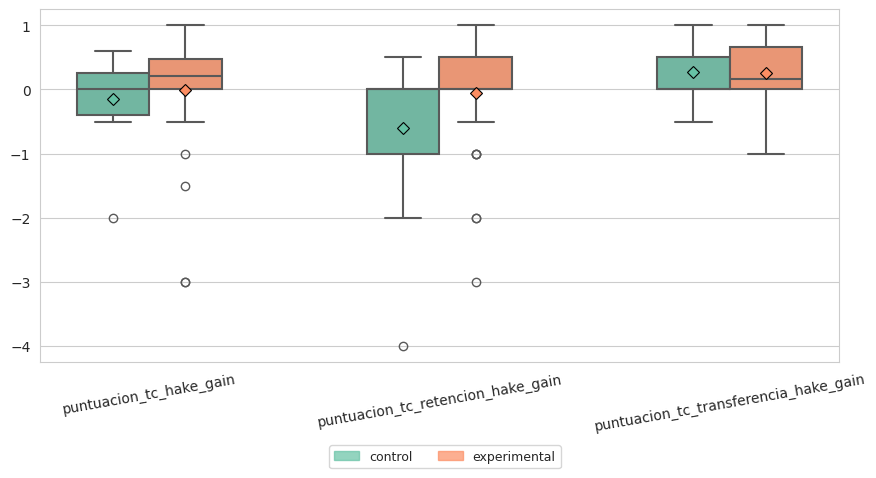

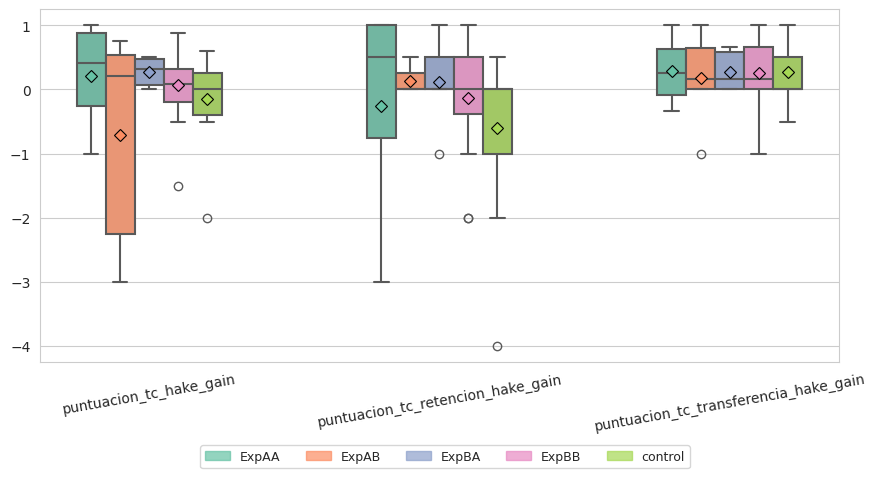


── CONDICIÓN: BAJA ──

n = 69


grupo_segmented,count,prop
str,u32,f64
"""control""",45,0.65
"""ExpBA""",3,0.04
"""ExpAA""",1,0.01
"""ExpAB""",6,0.09
"""ExpBB""",14,0.2


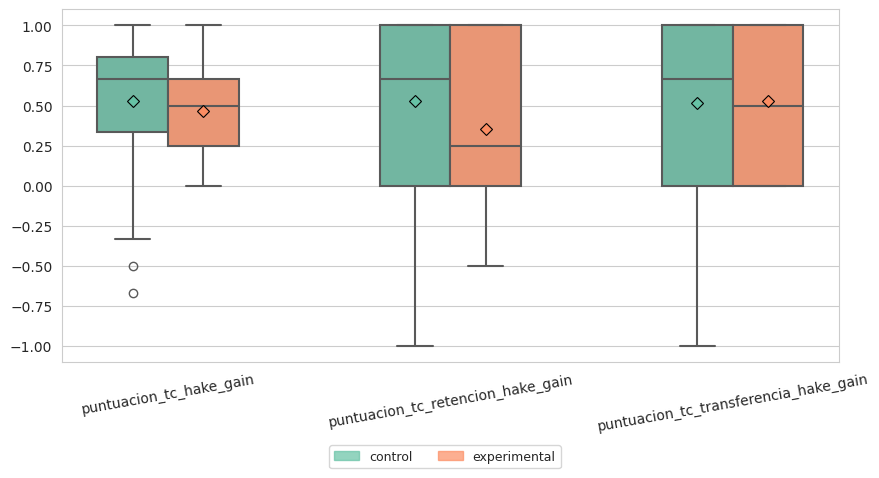

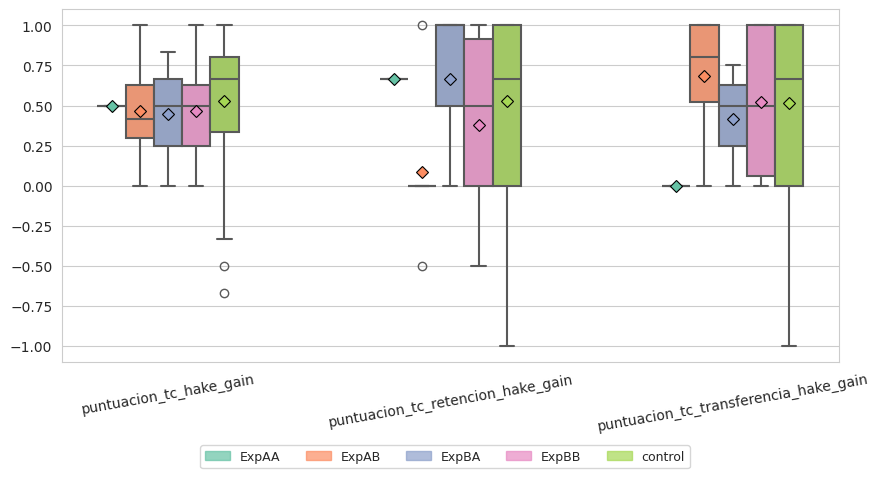

PUNTUACION_TCC_REL_CAT_POST

── CONDICIÓN: BAJA ──

n = 70


grupo_segmented,count,prop
str,u32,f64
"""ExpBA""",3,0.04
"""ExpAA""",4,0.06
"""ExpAB""",8,0.11
"""ExpBB""",19,0.27
"""control""",36,0.51


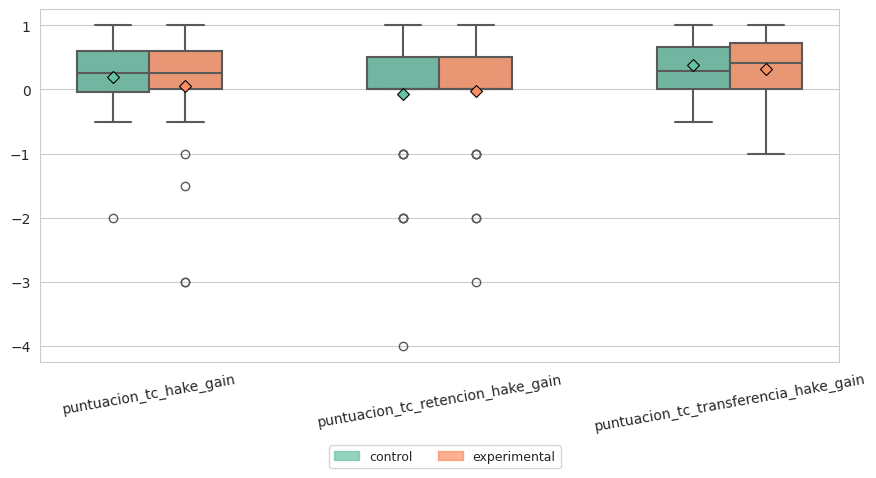

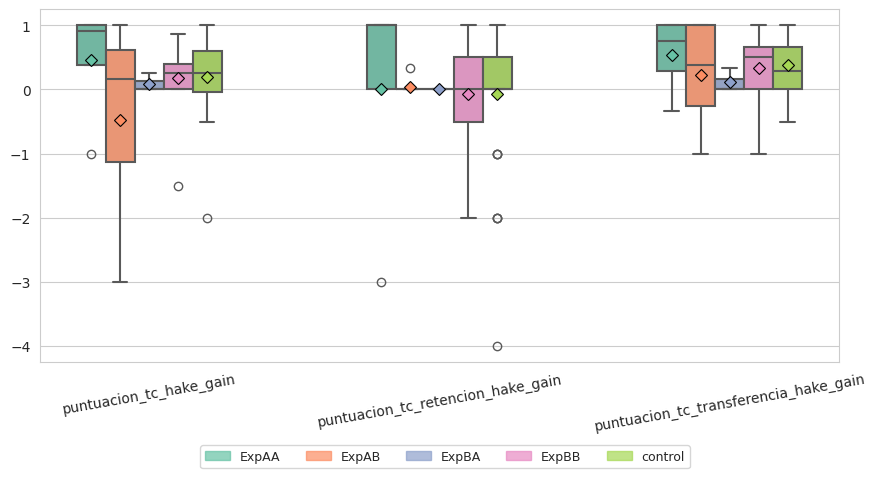


── CONDICIÓN: ALTA ──

n = 54


grupo_segmented,count,prop
str,u32,f64
"""ExpBA""",6,0.11
"""control""",26,0.48
"""ExpAB""",8,0.15
"""ExpAA""",1,0.02
"""ExpBB""",13,0.24


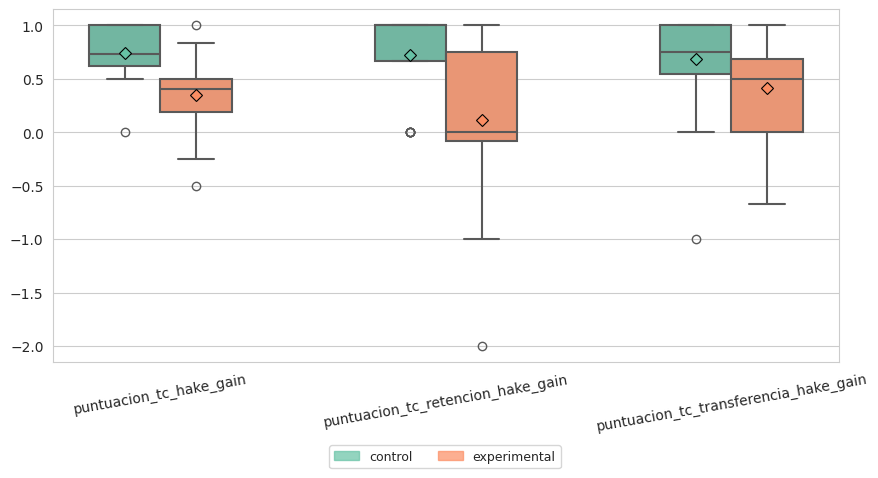

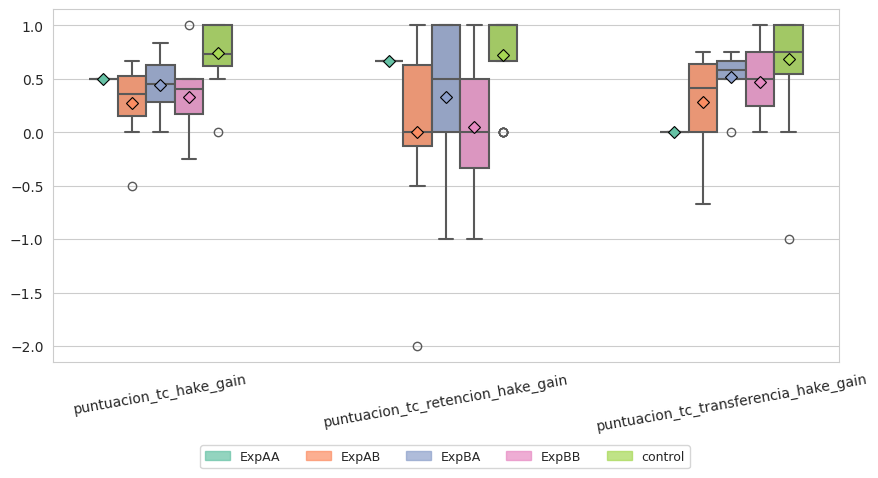


── CONDICIÓN: MEDIA ──

n = 64


grupo_segmented,count,prop
str,u32,f64
"""control""",35,0.55
"""ExpAA""",1,0.02
"""ExpBA""",3,0.05
"""ExpAB""",7,0.11
"""ExpBB""",18,0.28


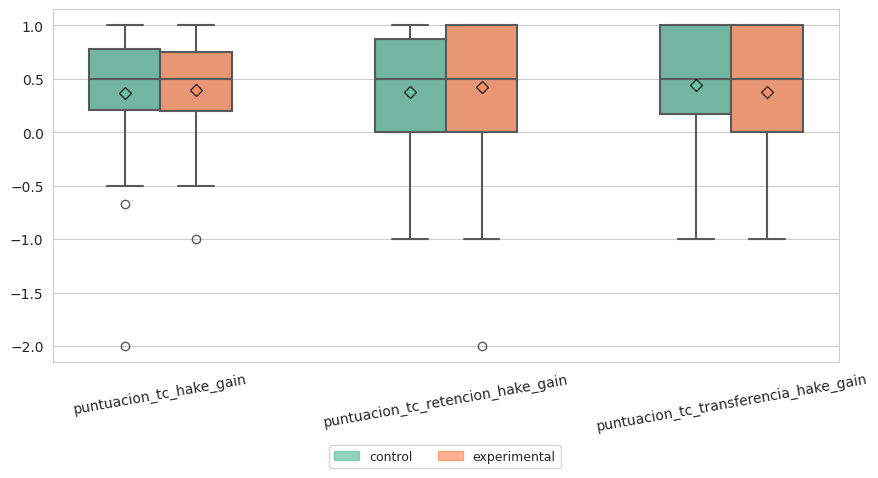

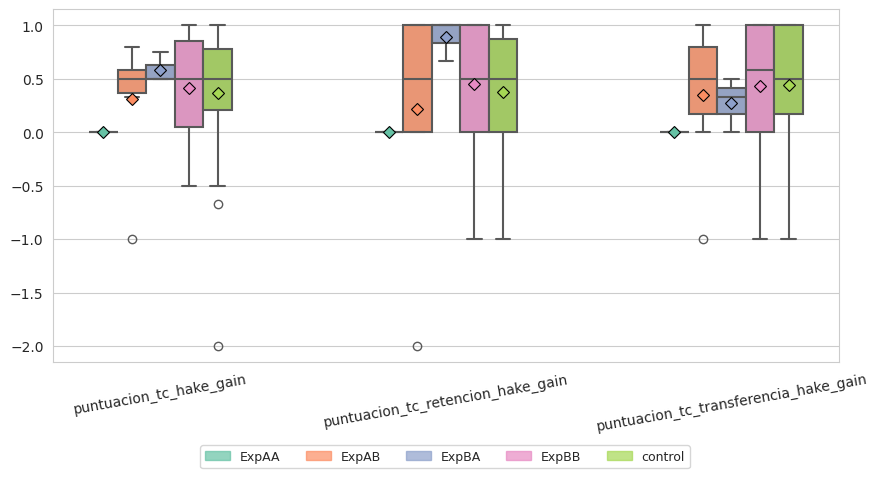

PUNTUACION_TA_CAT_PRE

── CONDICIÓN: ALTA ──

n = 58


grupo_segmented,count,prop
str,u32,f64
"""ExpAA""",3,0.05
"""control""",21,0.36
"""ExpBB""",17,0.29
"""ExpBA""",5,0.09
"""ExpAB""",12,0.21


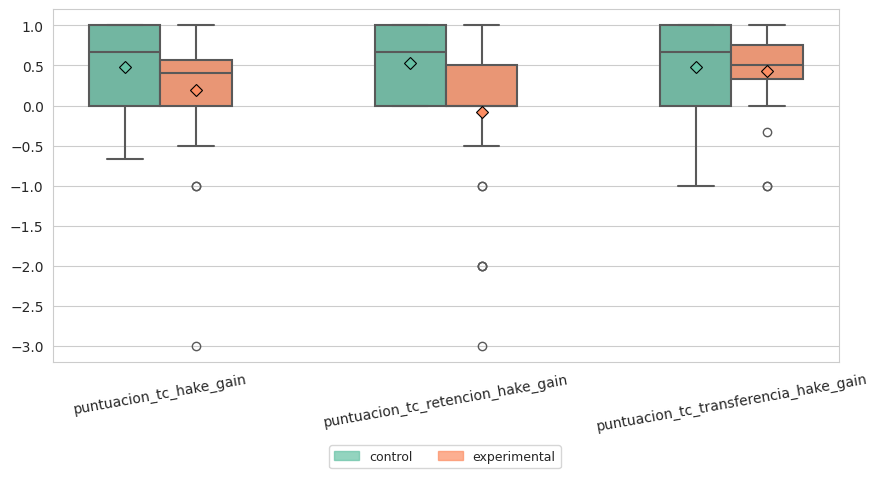

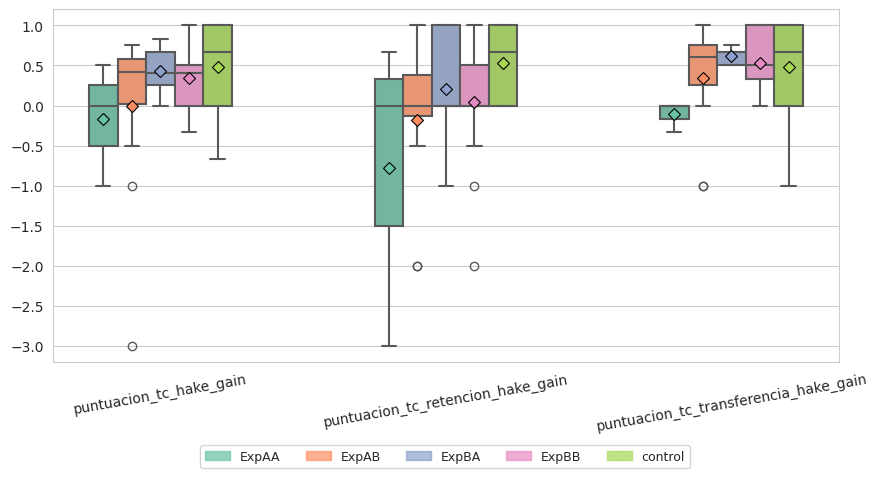


── CONDICIÓN: BAJA ──

n = 76


grupo_segmented,count,prop
str,u32,f64
"""ExpAA""",1,0.01
"""ExpAB""",4,0.05
"""ExpBA""",4,0.05
"""control""",47,0.62
"""ExpBB""",20,0.26


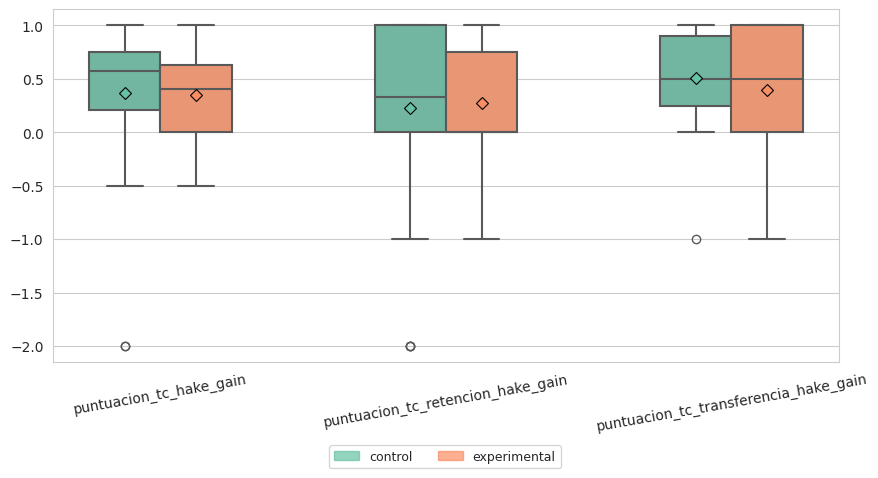

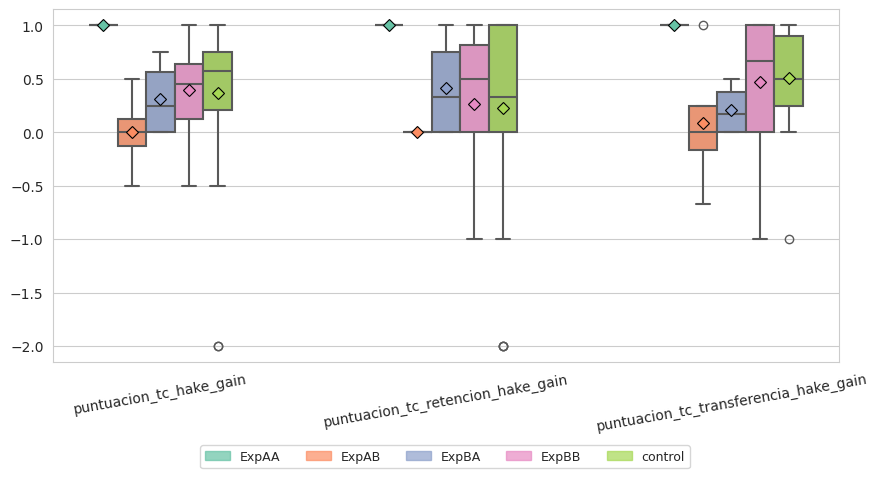


── CONDICIÓN: MEDIA ──

n = 54


grupo_segmented,count,prop
str,u32,f64
"""ExpAA""",2,0.04
"""ExpBA""",3,0.06
"""ExpBB""",13,0.24
"""control""",29,0.54
"""ExpAB""",7,0.13


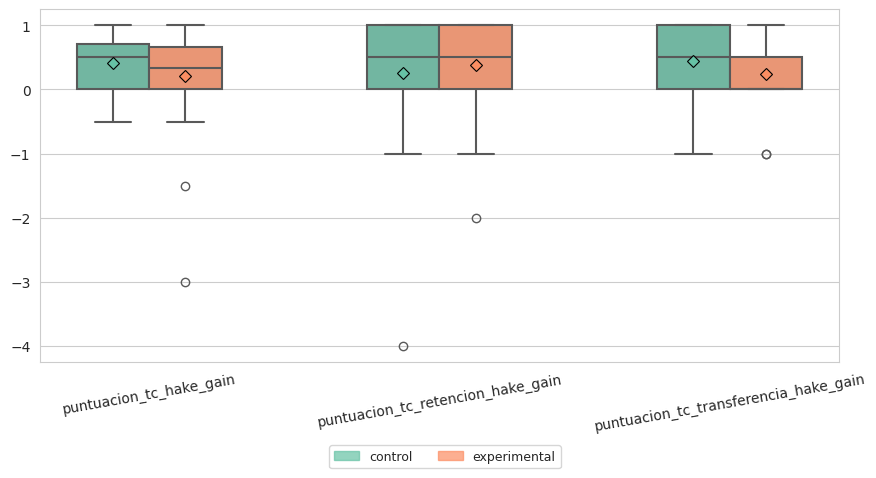

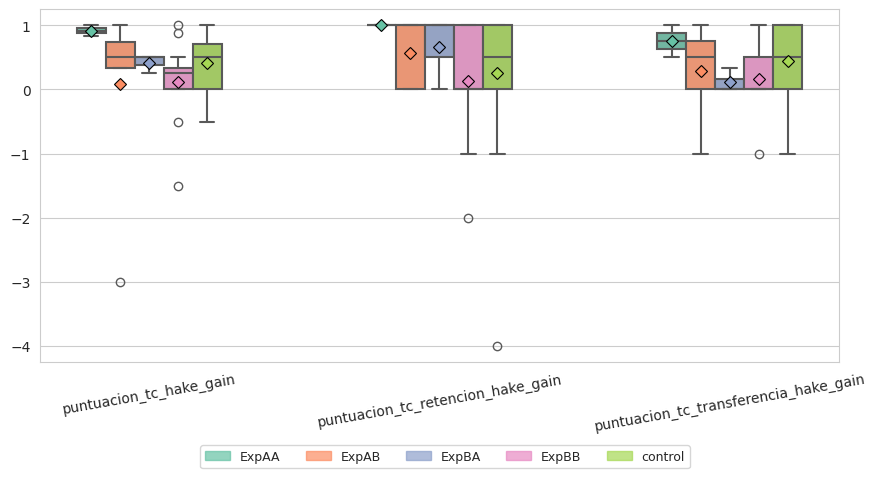

PUNTUACION_TA_CAT_POST

── CONDICIÓN: BAJA ──

n = 67


grupo_segmented,count,prop
str,u32,f64
"""ExpAB""",6,0.09
"""ExpBA""",2,0.03
"""ExpBB""",19,0.28
"""control""",36,0.54
"""ExpAA""",4,0.06


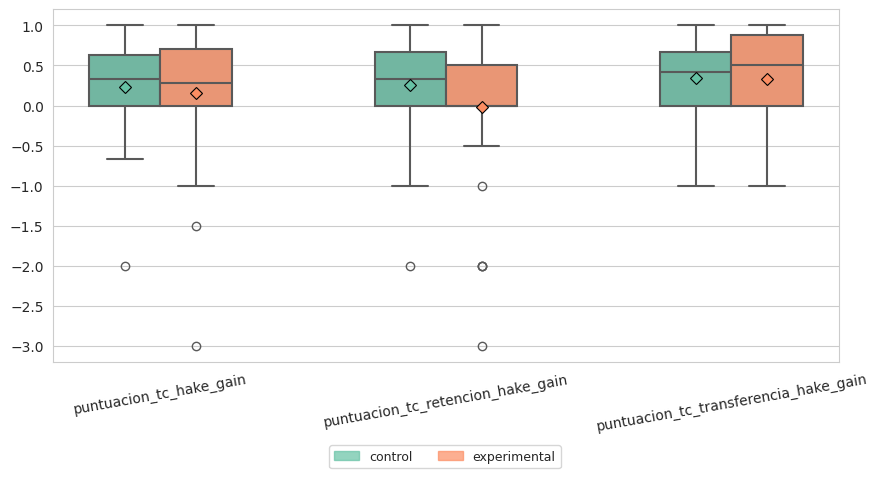

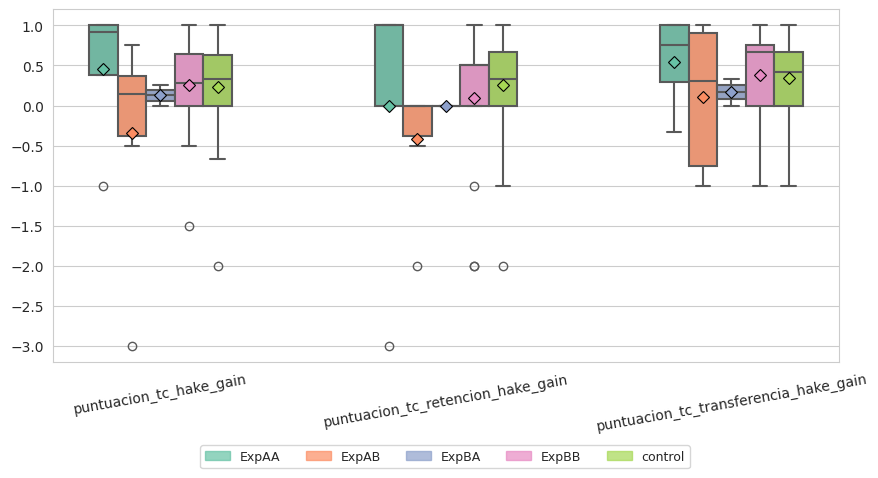


── CONDICIÓN: ALTA ──

n = 61


grupo_segmented,count,prop
str,u32,f64
"""ExpAA""",1,0.02
"""control""",26,0.43
"""ExpBB""",16,0.26
"""ExpBA""",8,0.13
"""ExpAB""",10,0.16


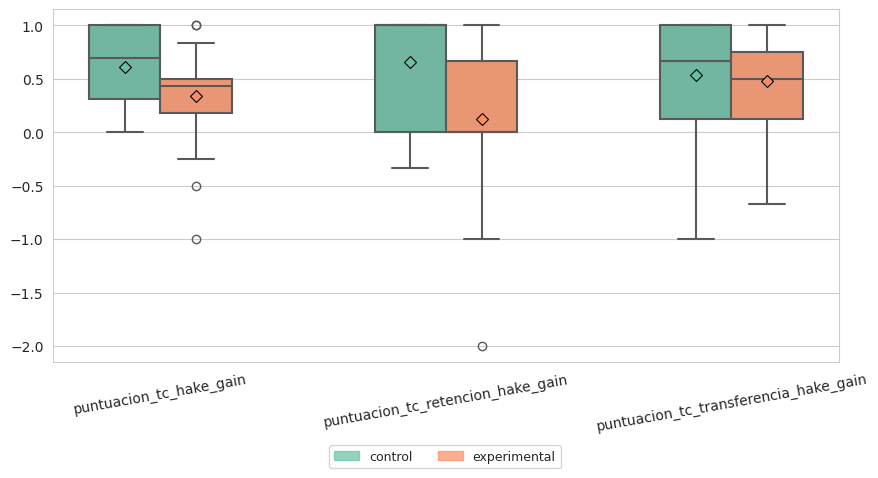

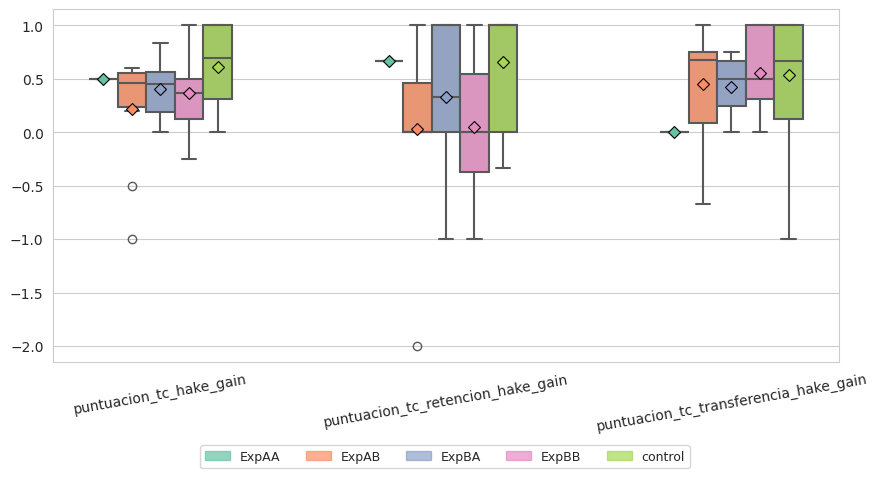


── CONDICIÓN: MEDIA ──

n = 60


grupo_segmented,count,prop
str,u32,f64
"""ExpAB""",7,0.12
"""control""",35,0.58
"""ExpBB""",15,0.25
"""ExpAA""",1,0.02
"""ExpBA""",2,0.03


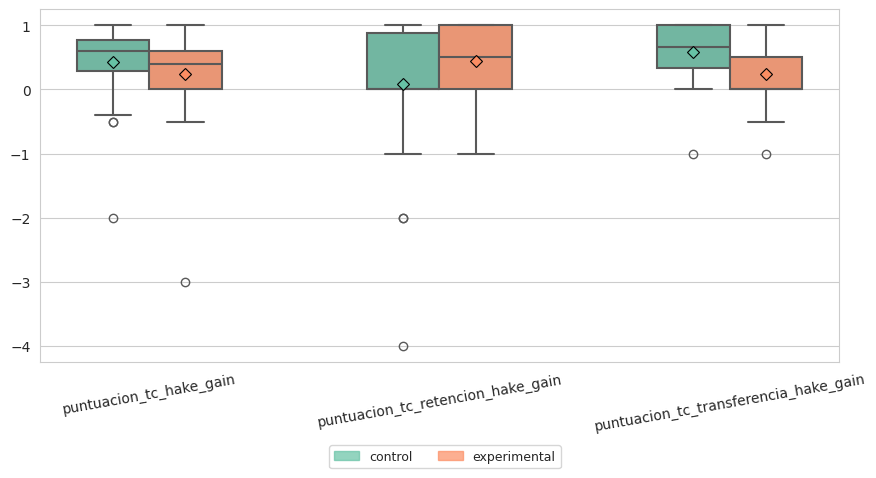

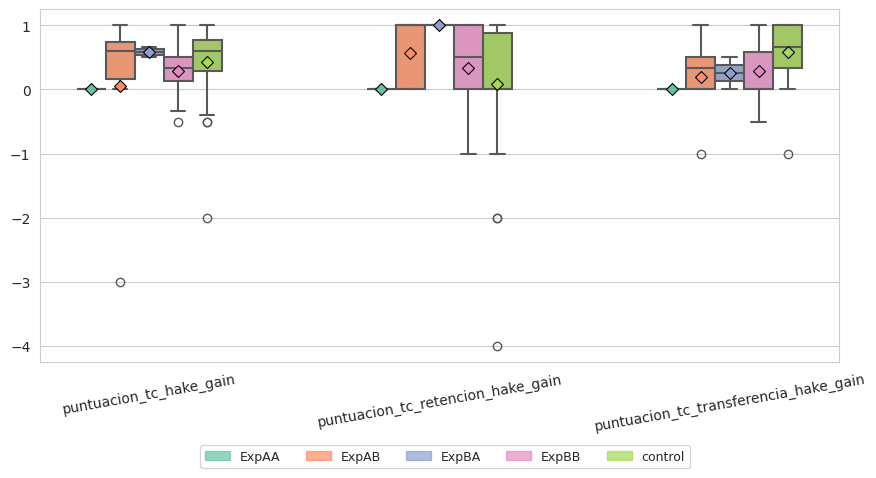

PUNTUACION_TC_CAT_PRE

── CONDICIÓN: BAJA ──

n = 63


grupo_segmented,count,prop
str,u32,f64
"""ExpBA""",3,0.05
"""control""",35,0.56
"""ExpAB""",9,0.14
"""ExpBB""",15,0.24
"""ExpAA""",1,0.02


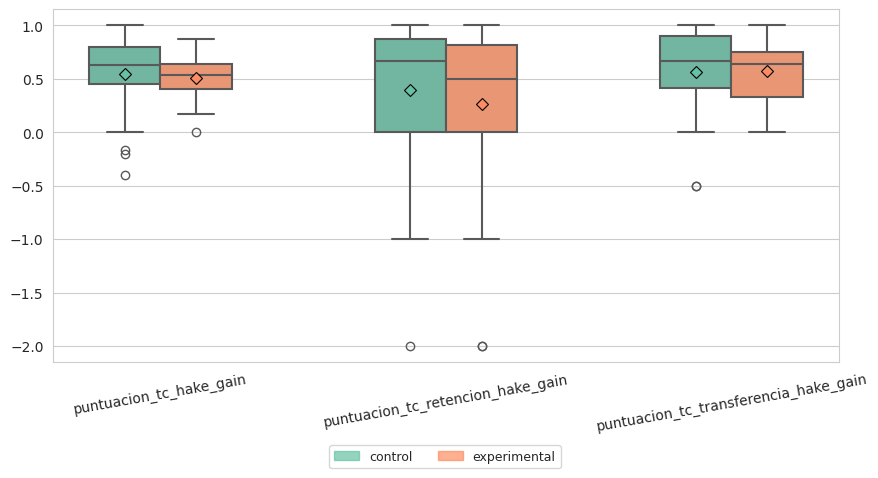

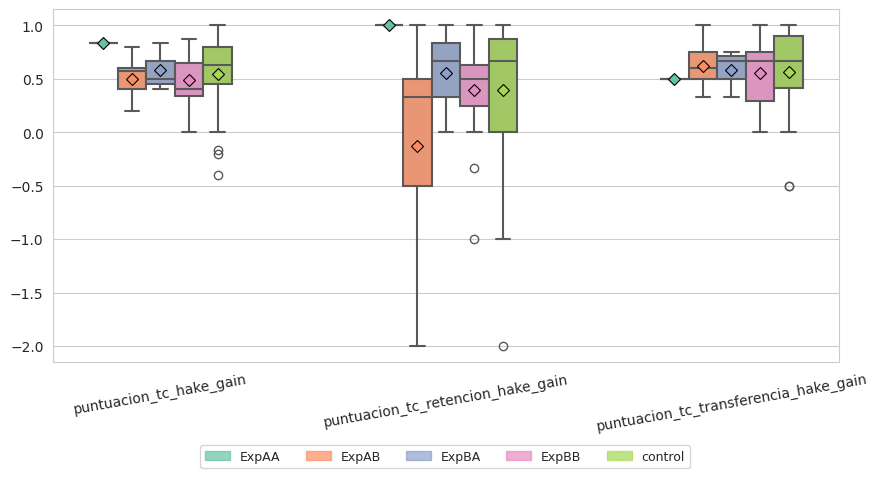


── CONDICIÓN: ALTA ──

n = 43


grupo_segmented,count,prop
str,u32,f64
"""control""",21,0.49
"""ExpAA""",1,0.02
"""ExpAB""",6,0.14
"""ExpBB""",13,0.3
"""ExpBA""",2,0.05


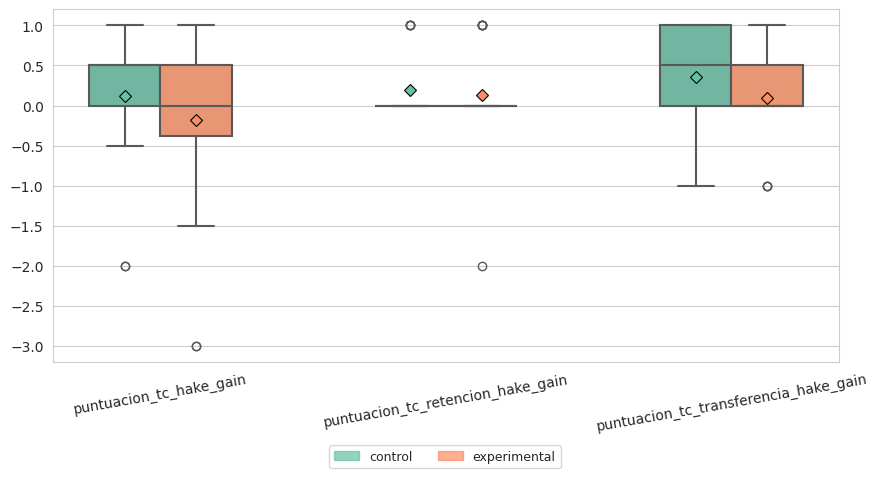

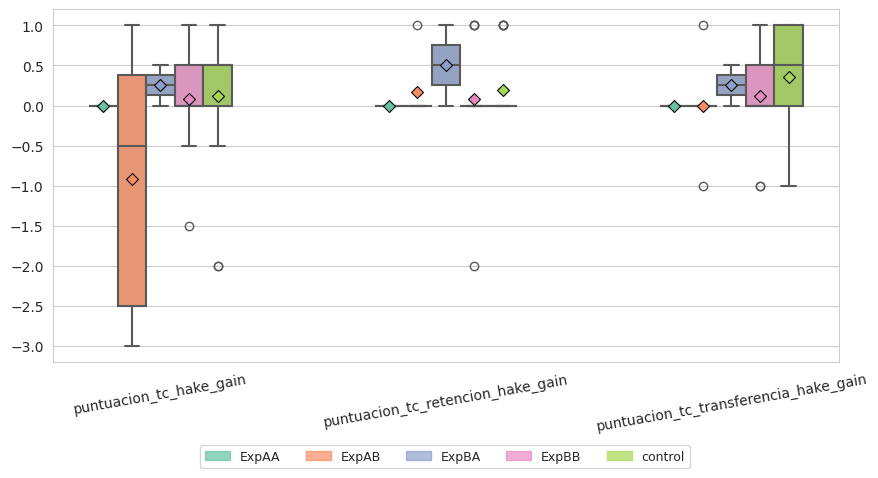


── CONDICIÓN: MEDIA ──

n = 82


grupo_segmented,count,prop
str,u32,f64
"""control""",41,0.5
"""ExpAB""",8,0.1
"""ExpBB""",22,0.27
"""ExpAA""",4,0.05
"""ExpBA""",7,0.09


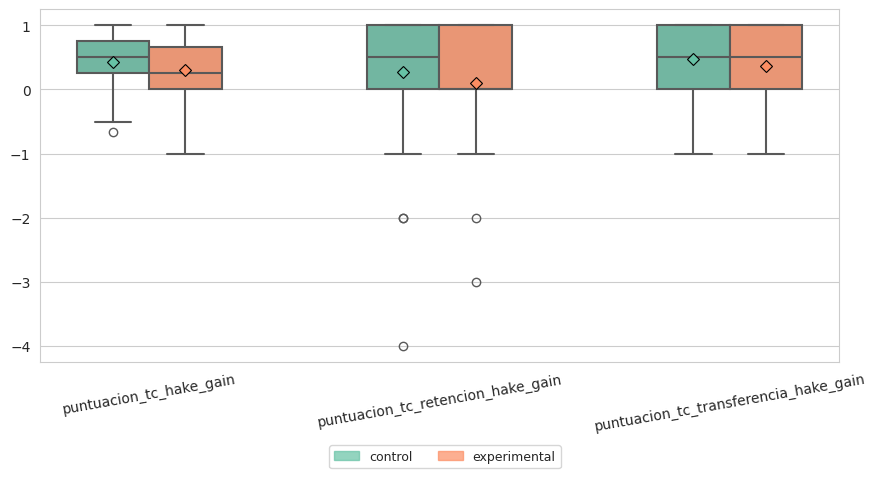

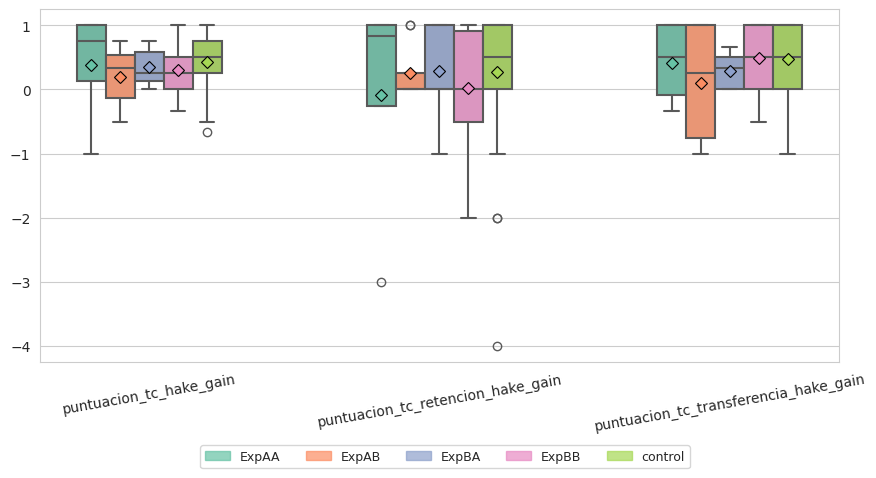

PUNTUACION_TC_CAT_POST

── CONDICIÓN: MEDIA ──

n = 84


grupo_segmented,count,prop
str,u32,f64
"""ExpAA""",3,0.04
"""control""",45,0.54
"""ExpAB""",11,0.13
"""ExpBA""",6,0.07
"""ExpBB""",19,0.23


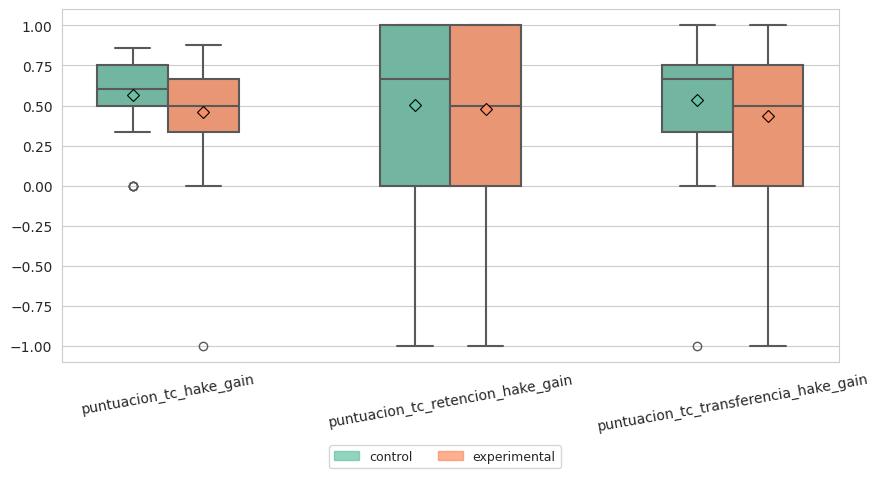

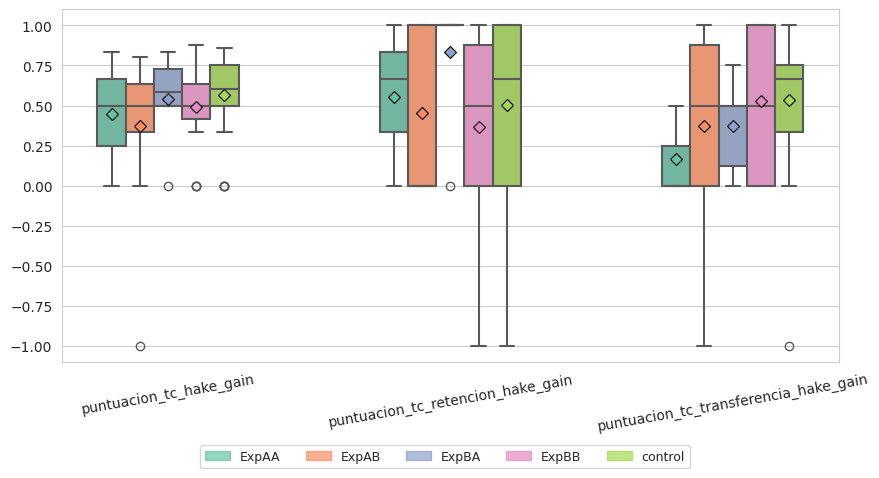


── CONDICIÓN: ALTA ──

n = 25


grupo_segmented,count,prop
str,u32,f64
"""ExpAB""",1,0.04
"""ExpBB""",5,0.2
"""control""",17,0.68
"""ExpAA""",2,0.08


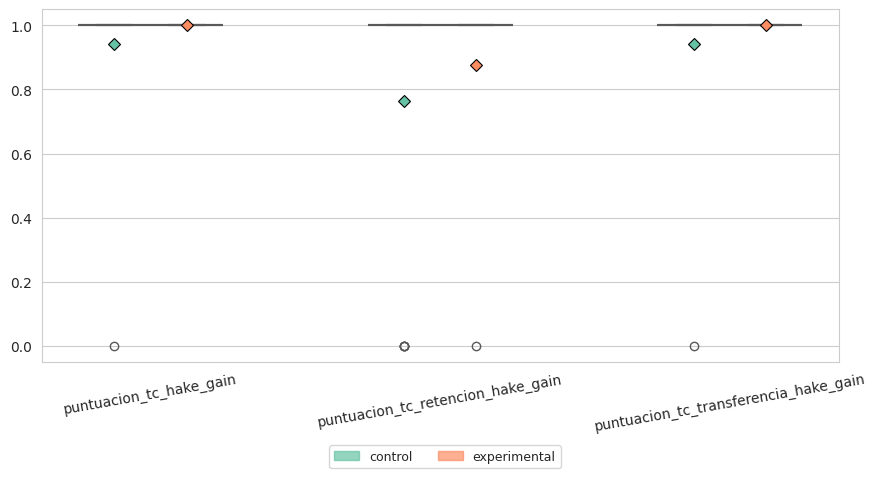

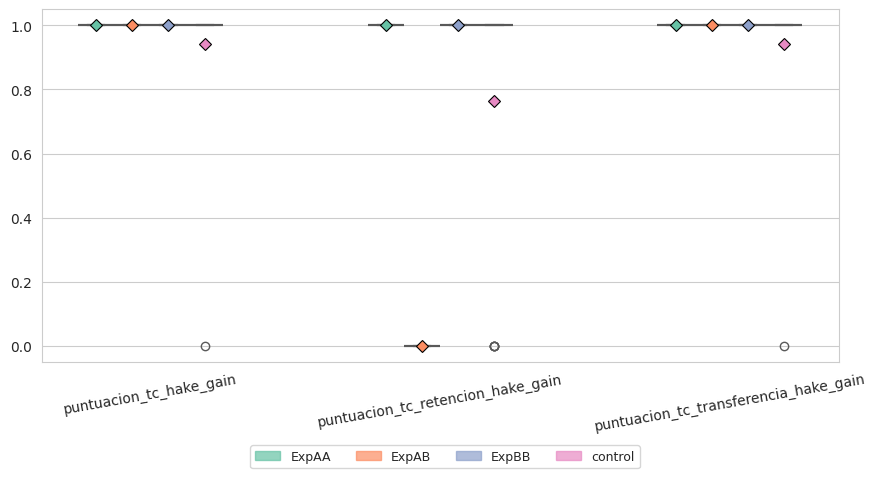


── CONDICIÓN: BAJA ──

n = 79


grupo_segmented,count,prop
str,u32,f64
"""ExpAA""",1,0.01
"""ExpAB""",11,0.14
"""ExpBB""",26,0.33
"""control""",35,0.44
"""ExpBA""",6,0.08


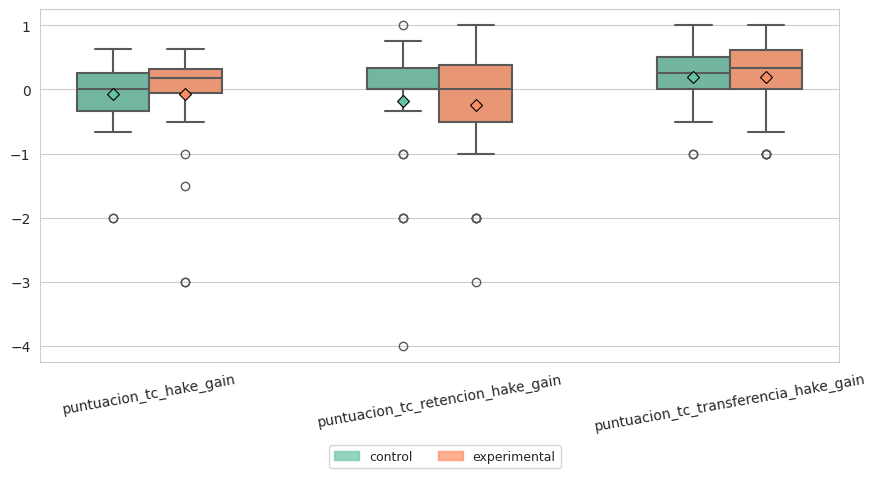

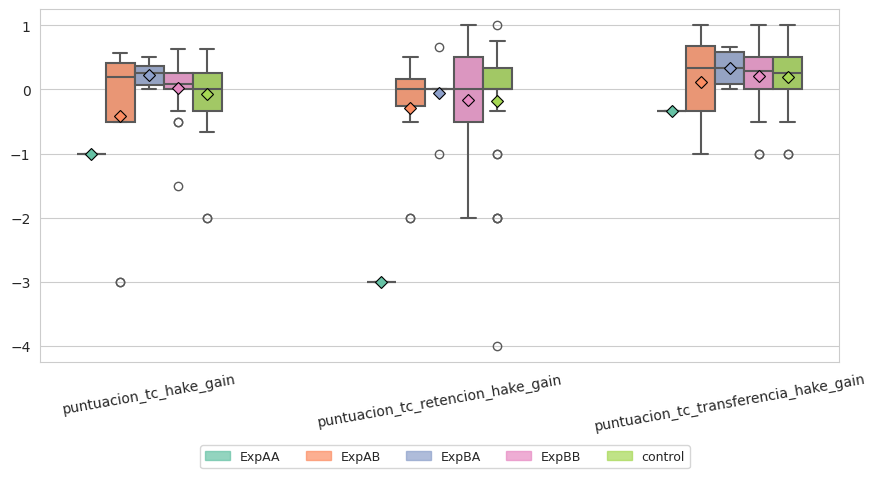

In [134]:
group_by_cols = [
    "centro",
    "puntuacion_tc_hake_gain_cat",
    "puntuacion_tcc_int_cat_post",
    "puntuacion_tcc_ext_cat_post",
    "puntuacion_tcc_rel_cat_post", 
    "puntuacion_ta_cat_pre",
    "puntuacion_ta_cat_post",
    "puntuacion_tc_cat_pre",
    "puntuacion_tc_cat_post"
]


for col in group_by_cols:

    print("="*140)
    print(col.upper())
    print("="*140)

    col_vals = forms_interactions_df[col].unique().to_list()

    for value in col_vals:

        df_filtered = (
            forms_interactions_df
            .filter(~pl.col('id').is_in(problematic_experimental_ids))
            .filter(pl.col(col) == value)
        )
        print(f"\n── CONDICIÓN: {value.upper()} ──\n")

        print(f"n = {len(df_filtered)}")
        display(df_filtered['grupo_segmented'].value_counts().with_columns((pl.col('count') / pl.col('count').sum()).round(2).alias('prop')))

        plot_quant_comparison(
            figsize=(9, 4),
            df=df_filtered,
            comparisons=[
                ["puntuacion_tc_hake_gain", "puntuacion_tc_retencion_hake_gain", "puntuacion_tc_transferencia_hake_gain"]
            ],
            group_by='grupo',
            showfliers=True,
            title=False,
            labelbottom=True,
            xlabel_rotation=10,
            bbox_to_anchor=(0.5, -0.2)
        )

        plot_quant_comparison(
            figsize=(9, 4),
            df=df_filtered,
            comparisons=[
                ["puntuacion_tc_hake_gain", "puntuacion_tc_retencion_hake_gain", "puntuacion_tc_transferencia_hake_gain"]
            ],
            group_by='grupo_segmented',
            showfliers=True,
            title=False,
            labelbottom=True,
            xlabel_rotation=10,
            bbox_to_anchor=(0.5, -0.2)
        )